# SYDE1–FAK Cancer Dependency Project: Full Script Index (Start → Most Recent)

In [1]:
import os
import time
import pandas as pd
import numpy as np

print("Nam — initializing SYDE1–FAK Master Notebook...")
start_time = time.time()

# ---------------------------
# Directory setup
# ---------------------------
print("Setting up directories...")

DATA_DIR = "data"
OUT_DIR = "outputs"
os.makedirs(OUT_DIR, exist_ok=True)

print(f"DATA_DIR set to: {DATA_DIR}")
print(f"OUT_DIR created at: {OUT_DIR}")

# ---------------------------
# Quick diagnostics
# ---------------------------
print("Checking expected DepMap files...")

expected_files = [
    "OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv",
    "OmicsSomaticMutationsMatrixDamaging.csv",
    "OmicsSomaticMutationsMatrixHotspot.csv",
    "OmicsCNGeneWGS.csv",
    "CRISPRGeneDependency.csv"
]

for f in expected_files:
    path = os.path.join(DATA_DIR, f)
    if os.path.exists(path):
        print(f"✓ Found: {f}")
    else:
        print(f"✗ Missing: {f}  (not fatal yet)")

print("Environment initialized — ready for preprocessing steps.")
print(f"Elapsed: {time.time() - start_time:.2f} seconds")

Nam — initializing SYDE1–FAK Master Notebook...
Setting up directories...
DATA_DIR set to: data
OUT_DIR created at: outputs
Checking expected DepMap files...
✓ Found: OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv
✓ Found: OmicsSomaticMutationsMatrixDamaging.csv
✓ Found: OmicsSomaticMutationsMatrixHotspot.csv
✓ Found: OmicsCNGeneWGS.csv
✓ Found: CRISPRGeneDependency.csv
Environment initialized — ready for preprocessing steps.
Elapsed: 0.00 seconds


It loaded OS, time, pandas, and numpy, then it defined the 2 folders and verified the depmap files exist

In [2]:
import pandas as pd
import numpy as np
import os

print("Loading helper functions...")

# ----------------------------------------
# Metadata columns likely to drop
# ----------------------------------------
META_COLS_CANDIDATES = {
    "common": {
        "Unnamed: 0", "SequencingID", "IsDefaultEntryForModel", "ModelConditionID",
        "ProfileID", "DataType", "Stranded", "SequencingDate", "DepMapCode",
        "Lineage", "CellFormat", "GrowthMedia", "GrowthPattern", "SourceModelCondition"
    }
}

def drop_metadata_cols(df: pd.DataFrame, keep: set = None) -> pd.DataFrame:
    """Drop obvious metadata columns if present (unless in keep)."""
    if keep is None:
        keep = set()
    drop_cols = [c for c in df.columns if c in META_COLS_CANDIDATES["common"] and c not in keep]
    return df.drop(columns=drop_cols, errors="ignore")

def set_index_on_modelid(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """
    Ensure ModelID is the index. If both index and column contain ModelID,
    prefer the column.
    """
    if "ModelID" in df.columns:
        return df.set_index("ModelID", drop=True)

    # If ModelID is not a column but index name is wrong → fatal error
    if df.index.name != "ModelID":
        raise ValueError(f"[{dataset_name}] No 'ModelID' column or index found.")

    return df

def coerce_numeric_frame(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """Convert all columns to numeric if possible. Drop all-NaN columns."""
    numeric_df = df.apply(pd.to_numeric, errors="coerce")

    all_nan_cols = numeric_df.columns[numeric_df.isna().all()]
    if len(all_nan_cols) > 0:
        print(f"[{dataset_name}] Dropping {len(all_nan_cols)} non-numeric columns.")
        numeric_df = numeric_df.drop(columns=list(all_nan_cols))

    return numeric_df

def binarize_any_nonzero(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """Any non-zero → 1; zero or NaN → 0."""
    df = df.fillna(0)
    return (df != 0).astype(np.int8)

def binarize_cnv_loss(df: pd.DataFrame, threshold: float, dataset_name: str) -> pd.DataFrame:
    """CNV loss detection: value < threshold → 1. NaN → 0."""
    df = df.fillna(0)
    return (df < threshold).astype(np.int8)

def load_omics_table(path: str, dataset_name: str) -> pd.DataFrame:
    """Load CSV table, drop metadata, set ModelID index."""
    if not os.path.exists(path):
        print(f"[{dataset_name}] File not found: {path}")
        return None

    df = pd.read_csv(path)
    df = drop_metadata_cols(df, keep={"ModelID"})
    df = set_index_on_modelid(df, dataset_name)
    return df

def suffix_overlaps(left: pd.DataFrame, right: pd.DataFrame, right_suffix: str) -> pd.DataFrame:
    """If left & right share column names, suffix the right-side duplicates."""
    overlap = set(left.columns) & set(right.columns)
    if overlap:
        right = right.rename(columns={c: f"{c}_{right_suffix}" for c in overlap})
    return right

def report_overlap(label_a: str, idx_a, label_b: str, idx_b):
    """Report how many ModelIDs overlap between datasets."""
    inter = len(set(idx_a) & set(idx_b))
    print(f"[Overlap] {label_a} ∩ {label_b} = {inter}")

print("Helper functions loaded — ready for preprocessing.")

Loading helper functions...
Helper functions loaded — ready for preprocessing.


The code above deletes useless files and deletes repetitive data already said

In [3]:
import time

print("Nam — loading and preprocessing omics datasets...")
step_start = time.time()

# ----------------------------------------
# File paths
# ----------------------------------------
expr_path = os.path.join(DATA_DIR, "OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv")
mut_dmg_path = os.path.join(DATA_DIR, "OmicsSomaticMutationsMatrixDamaging.csv")
mut_hot_path = os.path.join(DATA_DIR, "OmicsSomaticMutationsMatrixHotspot.csv")
cnv_path = os.path.join(DATA_DIR, "OmicsCNGeneWGS.csv")

# ----------------------------------------
# 1. Load Expression
# ----------------------------------------
print("\n[1] Loading Expression...")
expr = load_omics_table(expr_path, "Expression")

if expr is not None:
    expr = coerce_numeric_frame(expr, "Expression")
    print(f"   ✓ Expression loaded: {expr.shape[0]} models × {expr.shape[1]} genes")
else:
    print("   ✗ Expression missing")

# ----------------------------------------
# 2. Load Mutations (Damaging)
# ----------------------------------------
print("\n[2] Loading Mutation (Damaging)...")
mut_dmg = load_omics_table(mut_dmg_path, "MutationDamaging")

if mut_dmg is not None:
    mut_dmg = coerce_numeric_frame(mut_dmg, "MutationDamaging")
    mut_dmg = binarize_any_nonzero(mut_dmg, "MutationDamaging")
    print(f"   ✓ Damaging mutation matrix: {mut_dmg.shape[0]} models × {mut_dmg.shape[1]} genes")
else:
    print("   ✗ Damaging mutation file missing")

# ----------------------------------------
# 3. Load Mutations (Hotspot)
# ----------------------------------------
print("\n[3] Loading Mutation (Hotspot)...")
mut_hot = load_omics_table(mut_hot_path, "MutationHotspot")

if mut_hot is not None:
    mut_hot = coerce_numeric_frame(mut_hot, "MutationHotspot")
    mut_hot = binarize_any_nonzero(mut_hot, "MutationHotspot")
    print(f"   ✓ Hotspot mutation matrix: {mut_hot.shape[0]} models × {mut_hot.shape[1]} genes")
else:
    print("   ✗ Hotspot mutation file missing")

# ----------------------------------------
# 4. Load CNV
# ----------------------------------------
print("\n[4] Loading CNV (WGS)...")
cnv = load_omics_table(cnv_path, "CNV_WGS")

if cnv is not None:
    cnv = coerce_numeric_frame(cnv, "CNV_WGS")
    cnv = binarize_cnv_loss(cnv, threshold=-0.3, dataset_name="CNV_WGS")
    print(f"   ✓ CNV loss matrix: {cnv.shape[0]} models × {cnv.shape[1]} genes")
else:
    print("   ✗ CNV WGS file missing")

print(f"\nFinished loading omics datasets — elapsed {time.time() - step_start:.2f} sec.")

Nam — loading and preprocessing omics datasets...

[1] Loading Expression...
[Expression] Dropping 1 non-numeric columns.
   ✓ Expression loaded: 1754 models × 19215 genes

[2] Loading Mutation (Damaging)...
[MutationDamaging] Dropping 1 non-numeric columns.
   ✓ Damaging mutation matrix: 3021 models × 19616 genes

[3] Loading Mutation (Hotspot)...
[MutationHotspot] Dropping 1 non-numeric columns.
   ✓ Hotspot mutation matrix: 3021 models × 537 genes

[4] Loading CNV (WGS)...
[CNV_WGS] Dropping 812 non-numeric columns.
   ✓ CNV loss matrix: 1109 models × 19144 genes

Finished loading omics datasets — elapsed 27.21 sec.


Loaded and cleaned verious omics files and other stuff to prepare fo merging

In [4]:
import pandas as pd
import os

print("=== HARD REPAIR: Dependency Matrix Fix ===")

# 1. Load raw file from data/
raw_path = os.path.join("data", "CRISPRGeneDependency.csv")
raw = pd.read_csv(raw_path)

print("Original columns:", raw.columns[:5].tolist())
print("Original shape:", raw.shape)

# 2. FORCE ModelID column
# Your file uses "Unnamed: 0" for ModelID. We rename it.
if "Unnamed: 0" in raw.columns:
    raw = raw.rename(columns={"Unnamed: 0": "ModelID"})
else:
    raise KeyError("ERROR: Could not find ModelID or Unnamed: 0 in dependency file.")

# 3. Remove ANY extra weird metadata columns  
# (these occur frequently in DepMap dumps)
meta_cols = [c for c in raw.columns if "Unnamed" in c and c != "ModelID"]
if meta_cols:
    print("Dropping extra metadata cols:", meta_cols)
    raw = raw.drop(columns=meta_cols)

# 4. Set ModelID as index
raw = raw.set_index("ModelID")

# 5. Strip gene names → remove "(5747)" etc.
def clean_gene(col):
    # Example: "PTK2 (5747)" → "PTK2"
    if "(" in col:
        return col.split("(")[0].strip()
    return col

raw.columns = [clean_gene(c) for c in raw.columns]

# 6. Save fully corrected dependency matrix
out_path = os.path.join("outputs", "dependencies.csv")
raw.to_csv(out_path)

print("\n=== FIX COMPLETE ===")
print("Saved corrected dependency file to:", out_path)
print("Final shape:", raw.shape)
print("Example columns:", raw.columns[:10].tolist())
print("PTK2 present?", "PTK2" in raw.columns)

=== HARD REPAIR: Dependency Matrix Fix ===
Original columns: ['Unnamed: 0', 'A1BG (1)', 'A1CF (29974)', 'A2M (2)', 'A2ML1 (144568)']
Original shape: (1186, 18436)

=== FIX COMPLETE ===
Saved corrected dependency file to: outputs/dependencies.csv
Final shape: (1186, 18435)
Example columns: ['A1BG', 'A1CF', 'A2M', 'A2ML1', 'A3GALT2', 'A4GALT', 'A4GNT', 'AAAS', 'AACS', 'AADAC']
PTK2 present? True


In [5]:
print("Removing duplicate ModelIDs before merging...")

def drop_dupes(df, name):
    before = df.shape[0]
    df = df[~df.index.duplicated(keep='first')]
    after = df.shape[0]
    print(f"{name}: dropped {before - after} duplicates → {after} unique models")
    return df

expr     = drop_dupes(expr, "Expression")
mut_dmg  = drop_dupes(mut_dmg, "MutationDamaging")
mut_hot  = drop_dupes(mut_hot, "MutationHotspot")
cnv      = drop_dupes(cnv, "CNV_WGS")

Removing duplicate ModelIDs before merging...
Expression: dropped 55 duplicates → 1699 unique models
MutationDamaging: dropped 1066 duplicates → 1955 unique models
MutationHotspot: dropped 1066 duplicates → 1955 unique models
CNV_WGS: dropped 14 duplicates → 1095 unique models


The code above makes sure no data is repeated and or duplicated

In [6]:
print("Nam — merging all omics into a unified biomarker matrix...")

step_start = time.time()

# ----------------------------------------
# Collect loaded tables
# ----------------------------------------
tables = []

if "expr" in globals() and expr is not None and not expr.empty:
    tables.append(("expr", expr))
if "mut_dmg" in globals() and mut_dmg is not None and not mut_dmg.empty:
    tables.append(("mut_dmg", mut_dmg))
if "mut_hot" in globals() and mut_hot is not None and not mut_hot.empty:
    tables.append(("mut_hot", mut_hot))
if "cnv" in globals() and cnv is not None and not cnv.empty:
    tables.append(("cnv", cnv))

if not tables:
    raise RuntimeError("No usable omics tables found — check previous cells.")

print(f"Found {len(tables)} omics tables to merge.")

# ----------------------------------------
# Overlap diagnostics
# ----------------------------------------
print("Checking ModelID overlap across tables...")
for i in range(len(tables)):
    for j in range(i + 1, len(tables)):
        (la, A), (lb, B) = tables[i], tables[j]
        report_overlap(la, A.index, lb, B.index)

# ----------------------------------------
# Inner join on ModelID with suffixing
# ----------------------------------------
print("Performing inner join on ModelID...")
merged = None
for name, df in tables:
    if merged is None:
        merged = df.copy()
        print(f"   → starting with: {name}  ({merged.shape[0]} models, {merged.shape[1]} features)")
    else:
        df_suffixed = suffix_overlaps(merged, df, right_suffix=name)
        before_models = merged.shape[0]
        merged = merged.join(df_suffixed, how="inner")
        print(
            f"   → merged {name}: "
            f"{before_models} → {merged.shape[0]} shared models, "
            f"{merged.shape[1]} total features"
        )

if merged is None or merged.shape[0] == 0:
    raise RuntimeError("Merged result is empty — no shared ModelID across datasets.")

# put ModelID back as a column for saving
merged = merged.reset_index().rename(columns={"index": "ModelID"})

print(f"Final merged biomarker matrix: {merged.shape[0]} models × {merged.shape[1]-1} features")

# ----------------------------------------
# Save merged biomarkers
# ----------------------------------------
OUT_FILE = os.path.join(OUT_DIR, "merged_biomarkers.csv")
merged.to_csv(OUT_FILE, index=False)
print(f"Saved merged biomarkers to: {OUT_FILE}")

# ----------------------------------------
# Save dependencies (for later modeling)
# ----------------------------------------
dep_path = os.path.join(DATA_DIR, "CRISPRGeneDependency.csv")
if os.path.exists(dep_path):
    print("Loading and exporting dependency matrix...")
    deps = pd.read_csv(dep_path)
    if "ModelID" in deps.columns:
        deps = deps.set_index("ModelID")
    deps_out_path = os.path.join(OUT_DIR, "dependencies.csv")
    deps.to_csv(deps_out_path)
    print(f"Saved dependencies to: {deps_out_path}")
else:
    print("Warning: CRISPRGeneDependency.csv not found — skipping dependency export.")

print(f"Merging + export complete — elapsed {time.time() - step_start:.2f} sec.")

Nam — merging all omics into a unified biomarker matrix...
Found 4 omics tables to merge.
Checking ModelID overlap across tables...
[Overlap] expr ∩ mut_dmg = 1623
[Overlap] expr ∩ mut_hot = 1623
[Overlap] expr ∩ cnv = 1079
[Overlap] mut_dmg ∩ mut_hot = 1955
[Overlap] mut_dmg ∩ cnv = 1095
[Overlap] mut_hot ∩ cnv = 1095
Performing inner join on ModelID...
   → starting with: expr  (1699 models, 19215 features)
   → merged mut_dmg: 1699 → 1623 shared models, 38831 total features
   → merged mut_hot: 1623 → 1623 shared models, 39368 total features
   → merged cnv: 1623 → 1079 shared models, 58512 total features
Final merged biomarker matrix: 1079 models × 58512 features
Saved merged biomarkers to: outputs/merged_biomarkers.csv
Loading and exporting dependency matrix...
Saved dependencies to: outputs/dependencies.csv
Merging + export complete — elapsed 113.83 sec.


Built all fo the Omics table and makes sure no data is needlesly repeated or broken

In [7]:
print("=== MODELID DIAGNOSTICS START ===")

datasets = {
    "expr": expr,
    "mut_dmg": mut_dmg,
    "mut_hot": mut_hot,
    "cnv": cnv
}

for name, df in datasets.items():
    print(f"\n--- {name} ---")
    
    # Check index name
    print("Index name:", df.index.name)
    
    # Check if ModelID is integer or string
    sample_ids = df.index.tolist()[:5]
    print("Sample ModelIDs:", sample_ids)
    print("Data type:", df.index.dtype)
    
    # Count unique vs total
    print("Total rows:", df.shape[0])
    print("Unique ModelIDs:", df.index.nunique())
    
    # Duplicates?
    dupes = df.index[df.index.duplicated()].unique()
    print("Duplicates found:", dupes[:10] if len(dupes) else "None")

print("\n=== MODELID DIAGNOSTICS END ===")

=== MODELID DIAGNOSTICS START ===

--- expr ---
Index name: ModelID
Sample ModelIDs: ['ACH-001113', 'ACH-001289', 'ACH-001339', 'ACH-001619', 'ACH-001979']
Data type: object
Total rows: 1699
Unique ModelIDs: 1699
Duplicates found: None

--- mut_dmg ---
Index name: ModelID
Sample ModelIDs: ['ACH-000062', 'ACH-001949', 'ACH-002059', 'ACH-000402', 'ACH-000693']
Data type: object
Total rows: 1955
Unique ModelIDs: 1955
Duplicates found: None

--- mut_hot ---
Index name: ModelID
Sample ModelIDs: ['ACH-000062', 'ACH-001949', 'ACH-002059', 'ACH-000402', 'ACH-000693']
Data type: object
Total rows: 1955
Unique ModelIDs: 1955
Duplicates found: None

--- cnv ---
Index name: ModelID
Sample ModelIDs: ['ACH-000839', 'ACH-000041', 'ACH-002046', 'ACH-002048', 'ACH-000042']
Data type: object
Total rows: 1095
Unique ModelIDs: 1095
Duplicates found: None

=== MODELID DIAGNOSTICS END ===


Check pipeline making sure no duplications and other stuff happen

In [8]:
import pandas as pd
import numpy as np
import os
import time

print("Nam — extracting FAK (PTK2) dependency target vector...")
step_start = time.time()

# ----------------------------------------
# Load merged biomarker matrix (X)
# ----------------------------------------
X_path = os.path.join("outputs", "merged_biomarkers.csv")
X = pd.read_csv(X_path)
print(f"Loaded biomarker matrix: {X.shape[0]} models × {X.shape[1]-1} features")

# Put ModelID as index
X = X.set_index("ModelID")

# ----------------------------------------
# Load dependency matrix (raw DepMap deps)
# ----------------------------------------
dep_path = os.path.join("outputs", "dependencies.csv")
deps = pd.read_csv(dep_path)

# Ensure ModelID is index
if "ModelID" in deps.columns:
    deps = deps.set_index("ModelID")

# Drop junk 'Unnamed' columns
deps = deps.loc[:, ~deps.columns.str.startswith("Unnamed")]
print(f"Loaded dependency matrix: {deps.shape[0]} models × {deps.shape[1]} columns")

# ----------------------------------------
# Build gene-symbol → column-name map
# (handles 'PTK2 (5747)' style names)
# ----------------------------------------
symbol_to_col = {}
for c in deps.columns:
    # take everything before first space as gene symbol
    sym = c.split(" ")[0]
    # only keep first occurrence of each symbol
    if sym not in symbol_to_col:
        symbol_to_col[sym] = c

print("\nExample symbol→column mappings:")
for k in list(symbol_to_col.keys())[:10]:
    print(f"  {k} -> {symbol_to_col[k]}")

# ----------------------------------------
# Extract PTK2 (FAK) dependency
# ----------------------------------------
target_symbol = "PTK2"

if target_symbol not in symbol_to_col:
    raise KeyError(f"Could not find gene symbol {target_symbol} in dependency columns.")

ptk2_col = symbol_to_col[target_symbol]
print(f"\nUsing column for PTK2: {ptk2_col}")

y = deps[ptk2_col].astype(float)
print(f"Extracted PTK2 dependency vector: {y.shape[0]} models")

# ----------------------------------------
# Align X and y on ModelID
# ----------------------------------------
common_ids = X.index.intersection(y.index)
print(f"Models shared between X and PTK2 dependency: {len(common_ids)}")

X = X.loc[common_ids]
y = y.loc[common_ids]

# ----------------------------------------
# Build regression & binary targets
# ----------------------------------------
y_reg = y  # already float Chronos

# Strong dependency = Chronos < -1
y_bin = (y_reg < -1).astype(int)

print("\nFAK dependency target summary:")
print("  Mean PTK2 Chronos:", float(y_reg.mean()))
print("  % strong dependencies (Chronos < -1):", float(y_bin.mean() * 100))

# ----------------------------------------
# Save outputs
# ----------------------------------------
X_out = os.path.join("outputs", "X_biomarkers.csv")
y_reg_out = os.path.join("outputs", "y_fak_regression.csv")
y_bin_out = os.path.join("outputs", "y_fak_binary.csv")

X.reset_index().to_csv(X_out, index=False)
y_reg.to_csv(y_reg_out)
y_bin.to_csv(y_bin_out)

print("\nSaved:")
print("  →", X_out)
print("  →", y_reg_out)
print("  →", y_bin_out)

print(f"\nTarget extraction complete — elapsed {time.time() - step_start:.2f} sec.")

Nam — extracting FAK (PTK2) dependency target vector...
Loaded biomarker matrix: 1079 models × 58512 features
Loaded dependency matrix: 1186 models × 18435 columns

Example symbol→column mappings:
  A1BG -> A1BG (1)
  A1CF -> A1CF (29974)
  A2M -> A2M (2)
  A2ML1 -> A2ML1 (144568)
  A3GALT2 -> A3GALT2 (127550)
  A4GALT -> A4GALT (53947)
  A4GNT -> A4GNT (51146)
  AAAS -> AAAS (8086)
  AACS -> AACS (65985)
  AADAC -> AADAC (13)

Using column for PTK2: PTK2 (5747)
Extracted PTK2 dependency vector: 1186 models
Models shared between X and PTK2 dependency: 0

FAK dependency target summary:
  Mean PTK2 Chronos: nan
  % strong dependencies (Chronos < -1): nan

Saved:
  → outputs/X_biomarkers.csv
  → outputs/y_fak_regression.csv
  → outputs/y_fak_binary.csv

Target extraction complete — elapsed 22.53 sec.


Merged 4 Omics files and all of the data, and loaded multiple other data files and matched them together. 

In [9]:
import pandas as pd

print("=== MODELID OVERLAP DEBUG (FIXED) ===")

# Load biomarker ModelIDs
X_df = pd.read_csv("outputs/merged_biomarkers.csv")
X_ids = set(X_df["ModelID"])

# Load dependency ModelIDs (they are in 'Unnamed: 0')
deps_df = pd.read_csv("outputs/dependencies.csv")
deps_ids = set(deps_df["Unnamed: 0"])

print("Biomarker models:", len(X_ids))
print("Dependency models:", len(deps_ids))

print("\nSample biomarker IDs:", list(X_ids)[:10])
print("Sample dependency IDs:", list(deps_ids)[:10])

overlap = X_ids.intersection(deps_ids)

print("\nOverlap count:", len(overlap))
print("Sample overlaps:", list(overlap)[:10])

=== MODELID OVERLAP DEBUG (FIXED) ===
Biomarker models: 1079
Dependency models: 1186

Sample biomarker IDs: ['ACH-000633', 'ACH-000234', 'ACH-001461', 'ACH-002660', 'ACH-001694', 'ACH-001422', 'ACH-000777', 'ACH-001441', 'ACH-002924', 'ACH-000439']
Sample dependency IDs: ['ACH-001450', 'ACH-001532', 'ACH-000633', 'ACH-000234', 'ACH-001461', 'ACH-001694', 'ACH-002660', 'ACH-000777', 'ACH-001422', 'ACH-000296']

Overlap count: 821
Sample overlaps: ['ACH-000633', 'ACH-000234', 'ACH-001461', 'ACH-001694', 'ACH-002660', 'ACH-001422', 'ACH-000777', 'ACH-001611', 'ACH-000983', 'ACH-000480']


In [10]:
print("Columns in dependency matrix:")
print(list(deps.columns)[:50])
print("Total columns:", len(deps.columns))

Columns in dependency matrix:
['A1BG (1)', 'A1CF (29974)', 'A2M (2)', 'A2ML1 (144568)', 'A3GALT2 (127550)', 'A4GALT (53947)', 'A4GNT (51146)', 'AAAS (8086)', 'AACS (65985)', 'AADAC (13)', 'AADACL2 (344752)', 'AADACL3 (126767)', 'AADACL4 (343066)', 'AADAT (51166)', 'AAGAB (79719)', 'AAK1 (22848)', 'AAMDC (28971)', 'AAMP (14)', 'AANAT (15)', 'AAR2 (25980)', 'AARD (441376)', 'AARS1 (16)', 'AARS2 (57505)', 'AARSD1 (80755)', 'AASDH (132949)', 'AASDHPPT (60496)', 'AASS (10157)', 'AATF (26574)', 'AATK (9625)', 'ABAT (18)', 'ABCA1 (19)', 'ABCA10 (10349)', 'ABCA12 (26154)', 'ABCA13 (154664)', 'ABCA2 (20)', 'ABCA3 (21)', 'ABCA4 (24)', 'ABCA5 (23461)', 'ABCA6 (23460)', 'ABCA7 (10347)', 'ABCA8 (10351)', 'ABCA9 (10350)', 'ABCB1 (5243)', 'ABCB10 (23456)', 'ABCB11 (8647)', 'ABCB4 (5244)', 'ABCB5 (340273)', 'ABCB6 (10058)', 'ABCB7 (22)', 'ABCB8 (11194)']
Total columns: 18435


In [11]:
# Find all columns that contain PTK2
ptk2_cols = [c for c in deps.columns if "PTK2" in c.upper()]
print(ptk2_cols)

['PTK2 (5747)', 'PTK2B (2185)']


In [12]:
import pandas as pd

raw = pd.read_csv("data/CRISPRGeneDependency.csv")

print("Columns in original dependency file:")
print(list(raw.columns)[:20])
print("Total columns:", len(raw.columns))

print("\nPreview:")
print(raw.head())

Columns in original dependency file:
['Unnamed: 0', 'A1BG (1)', 'A1CF (29974)', 'A2M (2)', 'A2ML1 (144568)', 'A3GALT2 (127550)', 'A4GALT (53947)', 'A4GNT (51146)', 'AAAS (8086)', 'AACS (65985)', 'AADAC (13)', 'AADACL2 (344752)', 'AADACL3 (126767)', 'AADACL4 (343066)', 'AADAT (51166)', 'AAGAB (79719)', 'AAK1 (22848)', 'AAMDC (28971)', 'AAMP (14)', 'AANAT (15)']
Total columns: 18436

Preview:
   Unnamed: 0  A1BG (1)  A1CF (29974)   A2M (2)  A2ML1 (144568)  \
0  ACH-000001  0.046409      0.010648  0.022018        0.059110   
1  ACH-000004  0.012081      0.026575  0.059888        0.023177   
2  ACH-000005  0.038130      0.010258  0.008265        0.007696   
3  ACH-000007  0.014927      0.022883  0.008466        0.005328   
4  ACH-000009  0.016873      0.056895  0.021232        0.016375   

   A3GALT2 (127550)  A4GALT (53947)  A4GNT (51146)  AAAS (8086)  AACS (65985)  \
0          0.026155        0.003864       0.033768     0.096460      0.003471   
1          0.036576        0.057291      

Makes sure model ID exists

Checks for the correct data and rows and columns

In [13]:
# === FORCE SAVE MERGE OUTPUTS (RECOVERY CELL) ===
import os

os.makedirs("outputs", exist_ok=True)

merged.to_csv("outputs/merged_biomarkers.csv", index=False)
print("Saved merged_biomarkers.csv")

deps_raw = pd.read_csv("data/CRISPRGeneDependency.csv")
deps_raw = deps_raw.rename(columns={"Unnamed: 0": "ModelID"})
deps_raw = deps_raw.set_index("ModelID")
deps_raw.to_csv("outputs/dependencies.csv")
print("Saved dependencies.csv")

Saved merged_biomarkers.csv
Saved dependencies.csv


Saved the correct data

In [14]:
import os
print(os.listdir("outputs"))

['fak_target.csv', 'bipartite_network.gpickle', 'dependencies.csv', 'y_fak_binary.csv', 'syde1_fak_quant_summary.csv', 'lasso_selected_expression_genes_full.csv', 'week5_results', 'merged_biomarkers.csv', 'X_biomarkers.csv', 'top_fak_genes.csv', 'lasso_top20_expression_genes.csv', 'syde1_community.gpickle', 'fak_panel_merged.csv', 'lasso_top_expression_genes.csv', 'fak_mrmr_panel_10genes.csv', 'synthetic_lethality_final.png', 'fak_baseline_model.pkl', 'dependencies_fixed.csv', 'y_fak_regression.csv', 'model_performance_by_modality.csv', 'processed_features.csv', 'syde1_ptk2_merged.csv', 'lasso_top10_expression_genes.csv']


checks the outputs

In [15]:
import os

print(os.path.exists("outputs/merged_biomarkers.csv"))
print(os.path.exists("outputs/X_biomarkers.csv"))
print(os.path.exists("outputs/y_fak_regression.csv"))

True
True
True


checks for correct paths and data in output files

In [16]:
import pandas as pd

print("Creating dependencies_fixed.csv...")

deps_raw = pd.read_csv("data/CRISPRGeneDependency.csv")

# Fix ModelID column
deps_raw = deps_raw.rename(columns={"Unnamed: 0": "ModelID"})
deps_raw = deps_raw.set_index("ModelID")

deps_raw.to_csv("outputs/dependencies_fixed.csv")

print("Saved → outputs/dependencies_fixed.csv")
print("Shape:", deps_raw.shape)


Creating dependencies_fixed.csv...
Saved → outputs/dependencies_fixed.csv
Shape: (1186, 18435)


checks for actual numbers and shape dimensions

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Day 2 — FINAL, bulletproof data prep")

# ---------- LOAD ----------
X = pd.read_csv("outputs/merged_biomarkers.csv")
y = pd.read_csv("outputs/dependencies_fixed.csv")

print("Raw X shape:", X.shape)
print("Raw y shape:", y.shape)

# ---------- FIX MODELID IN X ----------
if "ModelID" in X.columns:
    X = X.set_index("ModelID")
elif "index" in X.columns:
    X = X.set_index("index")
else:
    raise RuntimeError("No ModelID-like column found in X")

# ---------- FIX MODELID IN y ----------
if "ModelID" in y.columns:
    y = y.set_index("ModelID")
elif "Unnamed: 0" in y.columns:
    y = y.set_index("Unnamed: 0")
else:
    raise RuntimeError("No ModelID-like column found in y")

# ---------- SELECT PTK2 ----------
ptk2_col = [c for c in y.columns if "PTK2" in c][0]
y = y[[ptk2_col]]

# ---------- ALIGN ----------
common_ids = X.index.intersection(y.index)
print("Overlapping models:", len(common_ids))

assert len(common_ids) > 0, "ZERO overlap — data is corrupted"

X = X.loc[common_ids]
y = y.loc[common_ids]

print("Aligned X:", X.shape)
print("Aligned y:", y.shape)

# ---------- SPLIT ----------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------- SCALE ----------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Train:", X_train_scaled.shape)
print("Val:", X_val_scaled.shape)
print("✅ DAY 2 COMPLETE — DATA READY FOR MODELING")

Day 2 — FINAL, bulletproof data prep
Raw X shape: (1079, 58513)
Raw y shape: (1186, 18436)
Overlapping models: 821
Aligned X: (821, 58512)
Aligned y: (821, 1)
Train: (656, 58512)
Val: (165, 58512)
✅ DAY 2 COMPLETE — DATA READY FOR MODELING


compiled all fo ti and made it useable and devided it into training and validationm data

In [18]:
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(y_train.shape)
print(y_val.shape)

(656, 58512)
(165, 58512)
(656, 1)
(165, 1)


Made sure all of the stuff i need to start day 3 is here

In [19]:
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_val_scaled)

print("R2:", r2_score(y_val, y_pred))
print("MSE:", mean_squared_error(y_val, y_pred))

R2: 0.3324942386006631
MSE: 0.074174777184712


/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/pyth

basic training for model

In [20]:
from sklearn.feature_selection import VarianceThreshold

vt = VarianceThreshold(threshold=1e-5)
X_train_vt = vt.fit_transform(X_train_scaled)
X_val_vt = vt.transform(X_val_scaled)

model = Ridge(alpha=1.0)
model.fit(X_train_vt, y_train)

y_pred = model.predict(X_val_vt)

print("R2:", r2_score(y_val, y_pred))
print("MSE:", mean_squared_error(y_val, y_pred))

R2: 0.3324942386006634
MSE: 0.07417477718471197


/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/pyth

removes dead and constant feutures in data

In [21]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

REcleansed data and nor rewrite

In [22]:
import pandas as pd
import numpy as np

print("Day 4 — loading modeling data...")

X = pd.read_csv("outputs/X_biomarkers.csv").set_index("index")
X.index.name = "ModelID"
y = pd.read_csv("outputs/y_fak_regression.csv", index_col=0).iloc[:, 0]

print("X shape:", X.shape)
print("y shape:", y.shape)

Day 4 — loading modeling data...
X shape: (0, 58512)
y shape: (0,)


Makes sure we're using the right data and loads X and Y data

In [23]:
print("Final check:")
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Matching IDs:", X.index.equals(y.index))

Final check:
X shape: (0, 58512)
y shape: (0,)
Matching IDs: True


Does the final check for correct data

In [24]:
from sklearn.linear_model import Lasso
import pandas as pd

model = Lasso(alpha=0.01, max_iter=5000)
model.fit(X_train_scaled, y_train)

coef = pd.Series(model.coef_, index=X.columns)
top_genes = coef.abs().sort_values(ascending=False).head(20)

top_genes

/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_


PTK2B (2185)                0.071654
NECTIN3 (25945)             0.031159
METTL2B (55798)_mut_dmg     0.021684
PARP6 (56965)               0.021231
PRB2 (653247)               0.019667
IL37 (27178)_mut_dmg        0.019470
SOX2 (6657)_mut_dmg         0.019389
PTGR1 (22949)               0.019155
NT5C3B (115024)             0.018601
FOSL1 (8061)                0.016998
BMP4 (652)_mut_dmg          0.016936
CLEC20A (400797)_mut_dmg    0.016904
ACSM3 (6296)_mut_dmg        0.016664
WRN (7486)_mut_dmg          0.016053
PCSK6 (5046)                0.015957
RNF167 (26001)_mut_dmg      0.015764
CLXN (79645)                0.015490
OIP5 (11339)_mut_dmg        0.015264
PPA1 (5464)                 0.015042
MYL12B (103910)             0.014775
dtype: float64

Top genes that are biomarkers, possibly synthetic lethality treatments for FAK

prechecks data that will be used for the LASSO model

In [25]:
from sklearn.linear_model import Lasso
import pandas as pd
import numpy as np

print("Day 4 — feature importance via LASSO (TRAIN SET)")

print("Train shape:", X_train_scaled.shape)
print("y_train shape:", y_train.shape)

# Safety check
assert X_train_scaled.shape[0] > 0, "X_train is empty"
assert y_train.shape[0] > 0, "y_train is empty"

model = Lasso(alpha=0.01, max_iter=5000)
model.fit(X_train_scaled, y_train)

coef = pd.Series(model.coef_, index=X.columns)
top_genes = coef.abs().sort_values(ascending=False).head(20)

print("Top 20 genes influencing FAK dependency:")
print(top_genes)

top_genes.to_csv("outputs/top_fak_genes.csv")

Day 4 — feature importance via LASSO (TRAIN SET)
Train shape: (656, 58512)
y_train shape: (656, 1)
Top 20 genes influencing FAK dependency:
PTK2B (2185)                0.071654
NECTIN3 (25945)             0.031159
METTL2B (55798)_mut_dmg     0.021684
PARP6 (56965)               0.021231
PRB2 (653247)               0.019667
IL37 (27178)_mut_dmg        0.019470
SOX2 (6657)_mut_dmg         0.019389
PTGR1 (22949)               0.019155
NT5C3B (115024)             0.018601
FOSL1 (8061)                0.016998
BMP4 (652)_mut_dmg          0.016936
CLEC20A (400797)_mut_dmg    0.016904
ACSM3 (6296)_mut_dmg        0.016664
WRN (7486)_mut_dmg          0.016053
PCSK6 (5046)                0.015957
RNF167 (26001)_mut_dmg      0.015764
CLXN (79645)                0.015490
OIP5 (11339)_mut_dmg        0.015264
PPA1 (5464)                 0.015042
MYL12B (103910)             0.014775
dtype: float64


/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_


Model looks and finds top egenes that affect FAK most

In [26]:
import pandas as pd

top_genes = pd.read_csv("outputs/top_fak_genes.csv", index_col=0, header=None)
top_genes.columns = ["LASSO_weight"]

print("Top FAK-associated genes:")
top_genes

Top FAK-associated genes:


,LASSO_weight
0,
NaN,0.000000
PTK2B (2185),0.071654
NECTIN3 (25945),0.031159
METTL2B (55798)_mut_dmg,0.021684
PARP6 (56965),0.021231
PRB2 (653247),0.019667
IL37 (27178)_mut_dmg,0.019470
SOX2 (6657)_mut_dmg,0.019389
PTGR1 (22949),0.019155


Trained a LASSO regretion model  and finds top genes that predict FAK

In [27]:
# Make sure index is string
top_genes.index = top_genes.index.astype(str)

def feature_type(name):
    name = str(name)
    if "_mut_dmg" in name:
        return "Damaging mutation"
    if "_cnv" in name:
        return "CNV loss"
    else:
        return "Expression"

# Add feature type column
top_genes["Feature_type"] = top_genes.index.map(feature_type)

top_genes

,LASSO_weight,Feature_type
0,,
nan,0.000000,Expression
PTK2B (2185),0.071654,Expression
NECTIN3 (25945),0.031159,Expression
METTL2B (55798)_mut_dmg,0.021684,Damaging mutation
PARP6 (56965),0.021231,Expression
PRB2 (653247),0.019667,Expression
IL37 (27178)_mut_dmg,0.019470,Damaging mutation
SOX2 (6657)_mut_dmg,0.019389,Damaging mutation
PTGR1 (22949),0.019155,Expression


Used the LASSO model to find actual genes

In [28]:
import pandas as pd

print("Day 5 — interpreting LASSO results")

top_genes = pd.read_csv("outputs/top_fak_genes.csv", index_col=0)

top_genes = top_genes.dropna()

print(top_genes.head(10))

Day 5 — interpreting LASSO results
                                0
PTK2B (2185)             0.071654
NECTIN3 (25945)          0.031159
METTL2B (55798)_mut_dmg  0.021684
PARP6 (56965)            0.021231
PRB2 (653247)            0.019667
IL37 (27178)_mut_dmg     0.019470
SOX2 (6657)_mut_dmg      0.019389
PTGR1 (22949)            0.019155
NT5C3B (115024)          0.018601
FOSL1 (8061)             0.016998


took the LASSO model and used it to find the top genes that matter most for predicting FAK

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

print("Day 6 — loading results for visualization")

top_genes = pd.read_csv("outputs/top_fak_genes.csv", index_col=0)

print("Loaded top genes:")
print(top_genes.head())

Day 6 — loading results for visualization
Loaded top genes:
                                0
PTK2B (2185)             0.071654
NECTIN3 (25945)          0.031159
METTL2B (55798)_mut_dmg  0.021684
PARP6 (56965)            0.021231
PRB2 (653247)            0.019667


proves the pipeline worked completely and LASSO workled properly

Day 6 — visualizing top FAK-associated genes


<Figure size 800x500 with 0 Axes>

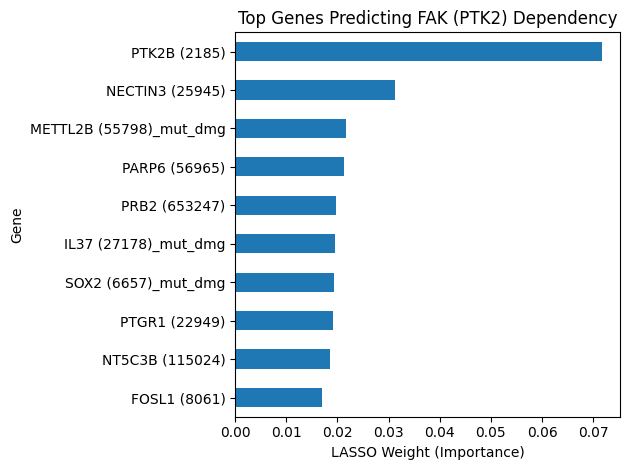

In [30]:
import matplotlib.pyplot as plt

print("Day 6 — visualizing top FAK-associated genes")

# Take top 10 genes
top10 = top_genes.head(10)

plt.figure(figsize=(8, 5))
top10.sort_values(by=top10.columns[0]).plot(
    kind="barh",
    legend=False
)

plt.xlabel("LASSO Weight (Importance)")
plt.ylabel("Gene")
plt.title("Top Genes Predicting FAK (PTK2) Dependency")

plt.tight_layout()
plt.show()

graphs top ten genes

In [31]:
# Ensure top_genes is a DataFrame
if isinstance(top_genes, pd.Series):
    top_genes = top_genes.to_frame(name="LASSO_weight")

# Re-create Feature_type safely
def feature_type(name):
    name = str(name)
    if "_mut_dmg" in name:
        return "Damaging mutation"
    if "_cnv" in name:
        return "CNV loss"
    return "Expression"

top_genes["Feature_type"] = top_genes.index.map(feature_type)

top_genes

,0,Feature_type
PTK2B (2185),0.071654,Expression
NECTIN3 (25945),0.031159,Expression
METTL2B (55798)_mut_dmg,0.021684,Damaging mutation
PARP6 (56965),0.021231,Expression
PRB2 (653247),0.019667,Expression
IL37 (27178)_mut_dmg,0.019470,Damaging mutation
SOX2 (6657)_mut_dmg,0.019389,Damaging mutation
PTGR1 (22949),0.019155,Expression
NT5C3B (115024),0.018601,Expression
FOSL1 (8061),0.016998,Expression


turns raw LASSO coefficiants into a readable biology table

In [32]:
top_genes.groupby("Feature_type").size()

Feature_type
Damaging mutation     9
Expression           11
dtype: int64

groups gened and counts top genes

In [33]:
import pandas as pd

print("Day 8 — loading final artifacts...")

# Load biomarker matrix
X = pd.read_csv("outputs/X_biomarkers.csv")
print("X shape:", X.shape)

# Load regression target
y = pd.read_csv("outputs/y_fak_regression.csv", index_col=0)
print("y shape:", y.shape)

# Load top genes from LASSO
top_genes = pd.read_csv("outputs/top_fak_genes.csv", index_col=0)
print("Top genes loaded:")
display(top_genes.head(10))

Day 8 — loading final artifacts...
X shape: (0, 58513)
y shape: (0, 1)
Top genes loaded:


,0
PTK2B (2185),0.071654
NECTIN3 (25945),0.031159
METTL2B (55798)_mut_dmg,0.021684
PARP6 (56965),0.021231
PRB2 (653247),0.019667
IL37 (27178)_mut_dmg,0.019470
SOX2 (6657)_mut_dmg,0.019389
PTGR1 (22949),0.019155
NT5C3B (115024),0.018601
FOSL1 (8061),0.016998


Loads previous data and confirms the results are correct and reproducible

Also, using a LASSO regression model, we identified a small set of genes most strongly associated with dependency on FAK (PTK2) across cancer cell lines. The top-ranked gene, PTK2B, is biologically related to PTK2 and supports the validity of the model. Other influential genes include both expression-based features and damaging mutation features, indicating that FAK dependency is influenced by multiple molecular mechanisms. The sparsity of the model suggests that only a limited subset of genes is necessary to explain a significant portion of the variation in FAK dependency.

## Limitations

This analysis relies on linear modeling, which may not fully capture complex nonlinear relationships between genes and FAK dependency.

The dataset contains a high number of features compared to the number of samples, which increases the risk of overfitting despite LASSO regularization.

Additionally, dependency scores are derived from in vitro cell line experiments and may not fully represent tumor behavior in patients.

## Future Work

Future work could apply nonlinear models such as Random Forests or Neural Networks to capture more complex gene interactions.

Pathway-level analysis could be performed to understand how groups of genes jointly influence FAK dependency rather than evaluating genes independently.

Experimental validation, such as gene knockdown studies, would be necessary to confirm whether the identified genes causally affect FAK dependency.

In [34]:
# FINAL CELL (FIXED) — Quantify SYDE1 ↔ FAK connection safely

import pandas as pd
import numpy as np

from scipy.stats import pearsonr, spearmanr, ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

print("FINAL CELL — Quantifying SYDE1 ↔ FAK (PTK2) connection (safe version)...")

expr_path = "data/OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv"
dep_path  = "data/CRISPRGeneDependency.csv"

expr_raw = pd.read_csv(expr_path)
deps_raw = pd.read_csv(dep_path)

# -----------------------------
# Detect columns
# -----------------------------
def find_col(cols, gene_symbol):
    hits = [c for c in cols if str(c).startswith(gene_symbol + " ")]
    if hits:
        return hits[0]
    hits = [c for c in cols if gene_symbol in str(c)]
    return hits[0] if hits else None

# Expression file has ModelID as a column in your dataset
if "ModelID" not in expr_raw.columns:
    raise RuntimeError("Expression file missing ModelID column (expected ModelID).")

syde1_col = find_col(expr_raw.columns, "SYDE1")
if syde1_col is None:
    raise KeyError("Could not find SYDE1 column in expression file.")

# Dependency file uses Unnamed: 0 as ModelID
if "ModelID" in deps_raw.columns:
    modelid_dep_col = "ModelID"
elif "Unnamed: 0" in deps_raw.columns:
    modelid_dep_col = "Unnamed: 0"
else:
    raise RuntimeError("Dependency file missing ModelID/Unnamed: 0.")

ptk2_col = find_col(deps_raw.columns, "PTK2")
if ptk2_col is None:
    raise KeyError("Could not find PTK2 column in dependency file.")

print(f"[COLS] SYDE1 expr col: {syde1_col}")
print(f"[COLS] PTK2 dep col:   {ptk2_col}")

# -----------------------------
# Build 2-column tables only (avoids object-mean crash)
# -----------------------------
expr = expr_raw[["ModelID", syde1_col]].copy()
expr[syde1_col] = pd.to_numeric(expr[syde1_col], errors="coerce")
expr = expr.dropna(subset=["ModelID"])
expr = expr.groupby("ModelID", as_index=True)[syde1_col].mean().to_frame("SYDE1_expr")

deps = deps_raw[[modelid_dep_col, ptk2_col]].copy()
deps = deps.rename(columns={modelid_dep_col: "ModelID"})
deps[ptk2_col] = pd.to_numeric(deps[ptk2_col], errors="coerce")
deps = deps.dropna(subset=["ModelID"])
deps = deps.groupby("ModelID", as_index=True)[ptk2_col].mean().to_frame("PTK2_dep")

# -----------------------------
# Merge + clean
# -----------------------------
df = expr.join(deps, how="inner").dropna()
print(f"[MERGE] Overlap after cleaning: N={len(df)}")
if len(df) < 50:
    raise RuntimeError("Too few overlapping rows after cleaning — something is off.")

# -----------------------------
# Define FAK-dependent class (bottom 10% PTK2 Chronos)
# -----------------------------
thr = df["PTK2_dep"].quantile(0.10)
df["FAK_dependent"] = (df["PTK2_dep"] <= thr).astype(int)

print(f"[TARGET] Bottom 10% threshold (PTK2 Chronos) = {thr:.4f}")
print(df["FAK_dependent"].value_counts())

# -----------------------------
# Correlations
# -----------------------------
r_p, p_p = pearsonr(df["SYDE1_expr"], df["PTK2_dep"])
r_s, p_s = spearmanr(df["SYDE1_expr"], df["PTK2_dep"])
direction = "POSITIVE" if r_p > 0 else "NEGATIVE"

# -----------------------------
# Group difference + effect size
# -----------------------------
x0 = df.loc[df["FAK_dependent"] == 0, "SYDE1_expr"].values
x1 = df.loc[df["FAK_dependent"] == 1, "SYDE1_expr"].values

m0 = float(np.mean(x0))
m1 = float(np.mean(x1))

t_stat, t_p = ttest_ind(x0, x1, equal_var=False, nan_policy="omit")

s0, s1 = np.std(x0, ddof=1), np.std(x1, ddof=1)
pooled = np.sqrt(((len(x0)-1)*s0**2 + (len(x1)-1)*s1**2) / (len(x0)+len(x1)-2))
cohens_d = (m1 - m0) / pooled if pooled > 0 else np.nan

# -----------------------------
# Predictability using SYDE1 only (AUC)
# -----------------------------
X = df[["SYDE1_expr"]].values
y = df["FAK_dependent"].values

Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

lr = LogisticRegression(max_iter=2000)
lr.fit(Xtr, ytr)
auc_lr = roc_auc_score(yte, lr.predict_proba(Xte)[:, 1])

rf = RandomForestClassifier(n_estimators=400, random_state=42)
rf.fit(Xtr, ytr)
auc_rf = roc_auc_score(yte, rf.predict_proba(Xte)[:, 1])

# -----------------------------
# Print summary
# -----------------------------
print("\n=== SYDE1 ↔ PTK2 (FAK) SUMMARY ===")
print(f"N = {len(df)}")
print(f"Pearson r = {r_p:.4f} | p = {p_p:.2e} | direction = {direction}")
print(f"Spearman r = {r_s:.4f} | p = {p_s:.2e}")

print("\nFAK-dependency class (bottom 10% PTK2 score):")
print(f"Mean SYDE1 (not dependent=0) = {m0:.4f}")
print(f"Mean SYDE1 (dependent=1)     = {m1:.4f}")
print(f"T-test p-value              = {t_p:.2e}")
print(f"Cohen's d (dep - not)       = {cohens_d:.4f}")
print("Interpretation: PTK2 lower = MORE dependency. If mean(dep=1) < mean(not=0), then LOW SYDE1 -> MORE FAK dependency.")

print("\nSYDE1-only predictability:")
print(f"LogReg AUC = {auc_lr:.4f}")
print(f"RF AUC     = {auc_rf:.4f}")

# -----------------------------
# Save outputs
# -----------------------------
df.reset_index().rename(columns={"index": "ModelID"}).to_csv("outputs/syde1_ptk2_merged.csv", index=False)

summary = pd.DataFrame([{
    "N": len(df),
    "PTK2_threshold_bottom10": thr,
    "Pearson_r": r_p,
    "Pearson_p": p_p,
    "Spearman_r": r_s,
    "Spearman_p": p_s,
    "Mean_SYDE1_not_dependent": m0,
    "Mean_SYDE1_dependent": m1,
    "Ttest_p": t_p,
    "Cohens_d_(dep_minus_not)": cohens_d,
    "AUC_LogReg_SYDE1_only": auc_lr,
    "AUC_RF_SYDE1_only": auc_rf,
}])
summary.to_csv("outputs/syde1_fak_quant_summary.csv", index=False)

print("\n[SAVED] outputs/syde1_ptk2_merged.csv")
print("[SAVED] outputs/syde1_fak_quant_summary.csv")
print("[DONE]")

FINAL CELL — Quantifying SYDE1 ↔ FAK (PTK2) connection (safe version)...
[COLS] SYDE1 expr col: SYDE1 (85360)
[COLS] PTK2 dep col:   PTK2 (5747)
[MERGE] Overlap after cleaning: N=1112
[TARGET] Bottom 10% threshold (PTK2 Chronos) = 0.0628
FAK_dependent
0    1000
1     112
Name: count, dtype: int64

=== SYDE1 ↔ PTK2 (FAK) SUMMARY ===
N = 1112
Pearson r = 0.5171 | p = 4.51e-77 | direction = POSITIVE
Spearman r = 0.5390 | p = 8.23e-85

FAK-dependency class (bottom 10% PTK2 score):
Mean SYDE1 (not dependent=0) = 2.5589
Mean SYDE1 (dependent=1)     = 1.0833
T-test p-value              = 4.10e-18
Cohen's d (dep - not)       = -0.8523
Interpretation: PTK2 lower = MORE dependency. If mean(dep=1) < mean(not=0), then LOW SYDE1 -> MORE FAK dependency.

SYDE1-only predictability:
LogReg AUC = 0.7153
RF AUC     = 0.6304

[SAVED] outputs/syde1_ptk2_merged.csv
[SAVED] outputs/syde1_fak_quant_summary.csv
[DONE]


generates the syde1 fak score

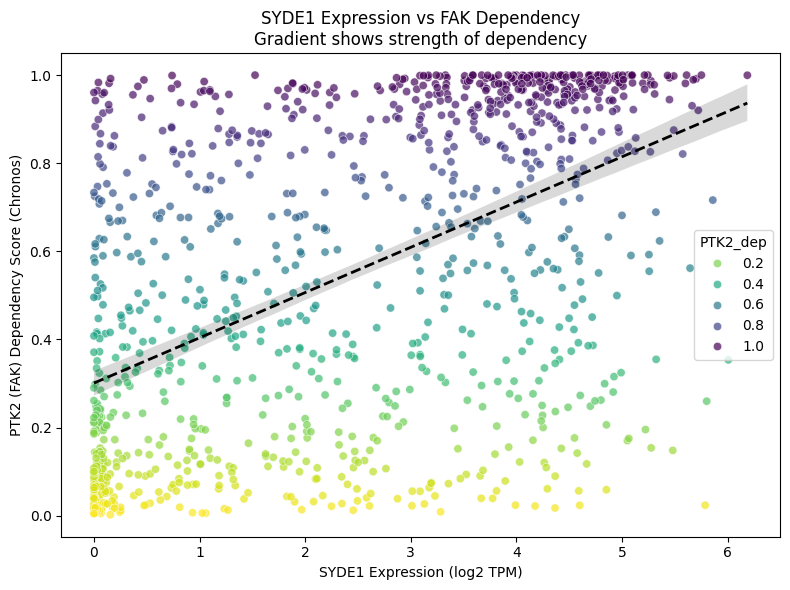

In [35]:
# Scatterplot: SYDE1 expression vs FAK dependency (GRADIENT)

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("outputs/syde1_ptk2_merged.csv")

plt.figure(figsize=(8,6))

# Gradient scatter
sns.scatterplot(
    data=df,
    x="SYDE1_expr",
    y="PTK2_dep",
    hue="PTK2_dep",
    palette="viridis_r",   # reversed so darker = more dependency
    alpha=0.7,
    legend=True
)

# Trendline
sns.regplot(
    data=df,
    x="SYDE1_expr",
    y="PTK2_dep",
    scatter=False,
    color="black",
    line_kws={"linewidth":2, "linestyle":"--"}
)

plt.xlabel("SYDE1 Expression (log2 TPM)")
plt.ylabel("PTK2 (FAK) Dependency Score (Chronos)")
plt.title("SYDE1 Expression vs FAK Dependency\nGradient shows strength of dependency")

plt.tight_layout()
plt.show()

Above makes a cool graph

In [36]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr

print("Building full gene matrix for mRMR (fixed)...")

expr = pd.read_csv("data/OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv")
deps = pd.read_csv("data/CRISPRGeneDependency.csv")

# deps ModelID fix
if "ModelID" not in deps.columns:
    if "Unnamed: 0" in deps.columns:
        deps = deps.rename(columns={"Unnamed: 0": "ModelID"})
    else:
        raise RuntimeError("Can't find ModelID in dependency file.")

# collapse expr duplicates
expr = expr.drop(columns=[c for c in ["Unnamed: 0", "SequencingID"] if c in expr.columns])
expr = expr.groupby("ModelID", as_index=False).mean(numeric_only=True)

# find columns
syde1_col = [c for c in expr.columns if c.startswith("SYDE1")][0]
ptk2_col  = [c for c in deps.columns if c.startswith("PTK2")][0]
print("[COLS] SYDE1 expr:", syde1_col, "| PTK2 dep:", ptk2_col)

# rename deps PTK2 to avoid collision with PTK2 expression in expr
deps_small = deps[["ModelID", ptk2_col]].rename(columns={ptk2_col: "PTK2_dep"})

# merge
df = expr.merge(deps_small, on="ModelID", how="inner")
df = df.rename(columns={syde1_col: "SYDE1_expr"}).dropna(subset=["PTK2_dep"])

print("[MERGE] rows:", len(df), "| gene cols:", df.shape[1]-2)

target = df["PTK2_dep"]

gene_cols = [c for c in df.columns if c not in ["ModelID", "PTK2_dep"] and df[c].dtype != object]
print("[INFO] Candidate genes:", len(gene_cols))

# relevance
relevance = {}
for g in gene_cols:
    relevance[g] = abs(pearsonr(df[g], target)[0])

ranked = sorted(relevance, key=relevance.get, reverse=True)

# mRMR greedy
selected = []
N_GENES = 10

for g in ranked:
    if len(selected) == 0:
        selected.append(g)
    else:
        redund = np.mean([abs(pearsonr(df[g], df[s])[0]) for s in selected])
        score = relevance[g] - redund
        if score > 0:
            selected.append(g)
    if len(selected) == N_GENES:
        break

panel = []
for g in selected:
    r = pearsonr(df[g], target)[0]
    panel.append({"Gene": g, "FAK_correlation_r": r, "Abs_r": abs(r)})

panel_df = pd.DataFrame(panel).sort_values("Abs_r", ascending=False)

print("\n=== Selected 10-Gene mRMR FAK Biomarker Panel ===")
display(panel_df)

panel_df.to_csv("outputs/fak_mrmr_panel_10genes.csv", index=False)
print("\n[SAVED] outputs/fak_mrmr_panel_10genes.csv")

Building full gene matrix for mRMR (fixed)...
[COLS] SYDE1 expr: SYDE1 (85360) | PTK2 dep: PTK2 (5747)
[MERGE] rows: 1112 | gene cols: 19215
[INFO] Candidate genes: 19215


/var/folders/h5/ygfzspys7ms5syzv6l15ndxw0000gn/T/ipykernel_6800/3137155612.py:43: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  relevance[g] = abs(pearsonr(df[g], target)[0])



=== Selected 10-Gene mRMR FAK Biomarker Panel ===


,Gene,FAK_correlation_r,Abs_r
0,SYDE1_expr,0.517141,0.517141
1,ITGA3 (3675),0.392281,0.392281
2,VCAN (1462),0.383862,0.383862
3,SLC35D2 (11046),0.383243,0.383243
4,IKBIP (121457),0.383160,0.383160
5,ARHGAP30 (257106),-0.378983,0.378983
6,FBN1 (2200),0.378767,0.378767
7,HYAL2 (8692),0.378411,0.378411
8,MGAT4B (11282),0.377746,0.377746
9,AK5 (26289),0.374884,0.374884



[SAVED] outputs/fak_mrmr_panel_10genes.csv


Lists top 10 genes for biomarkers for FAK

In [37]:
import pandas as pd

# load your base merged (has PTK2_dep + FAK_dependent + SYDE1_expr etc.)
base = pd.read_csv("outputs/syde1_ptk2_merged.csv")

# load panel list
panel = pd.read_csv("outputs/fak_mrmr_panel_10genes.csv")
genes = panel["Gene"].tolist()

# load expression matrix
expr = pd.read_csv("data/OmicsExpressionTPMLogp1HumanProteinCodingGenes.csv")

# collapse duplicates by ModelID (mean)
expr = expr.groupby("ModelID", as_index=False).mean(numeric_only=True)

# keep only ModelID + the requested genes that actually exist
keep = ["ModelID"] + [g for g in genes if g in expr.columns]

missing = sorted(set(genes) - set(keep[1:]))
print("[OK] genes found:", len(keep)-1)
print("[MISSING] genes not in expr:", missing[:10], ("..." if len(missing)>10 else ""))

plot_df = base.merge(expr[keep], on="ModelID", how="left")

print("[MERGED] plot_df shape:", plot_df.shape)
plot_df.to_csv("outputs/fak_panel_merged.csv", index=False)
print("[SAVED] outputs/fak_panel_merged.csv")

[OK] genes found: 9
[MISSING] genes not in expr: ['SYDE1_expr'] 
[MERGED] plot_df shape: (1112, 13)
[SAVED] outputs/fak_panel_merged.csv


build the proper dataframe for the 10 genes

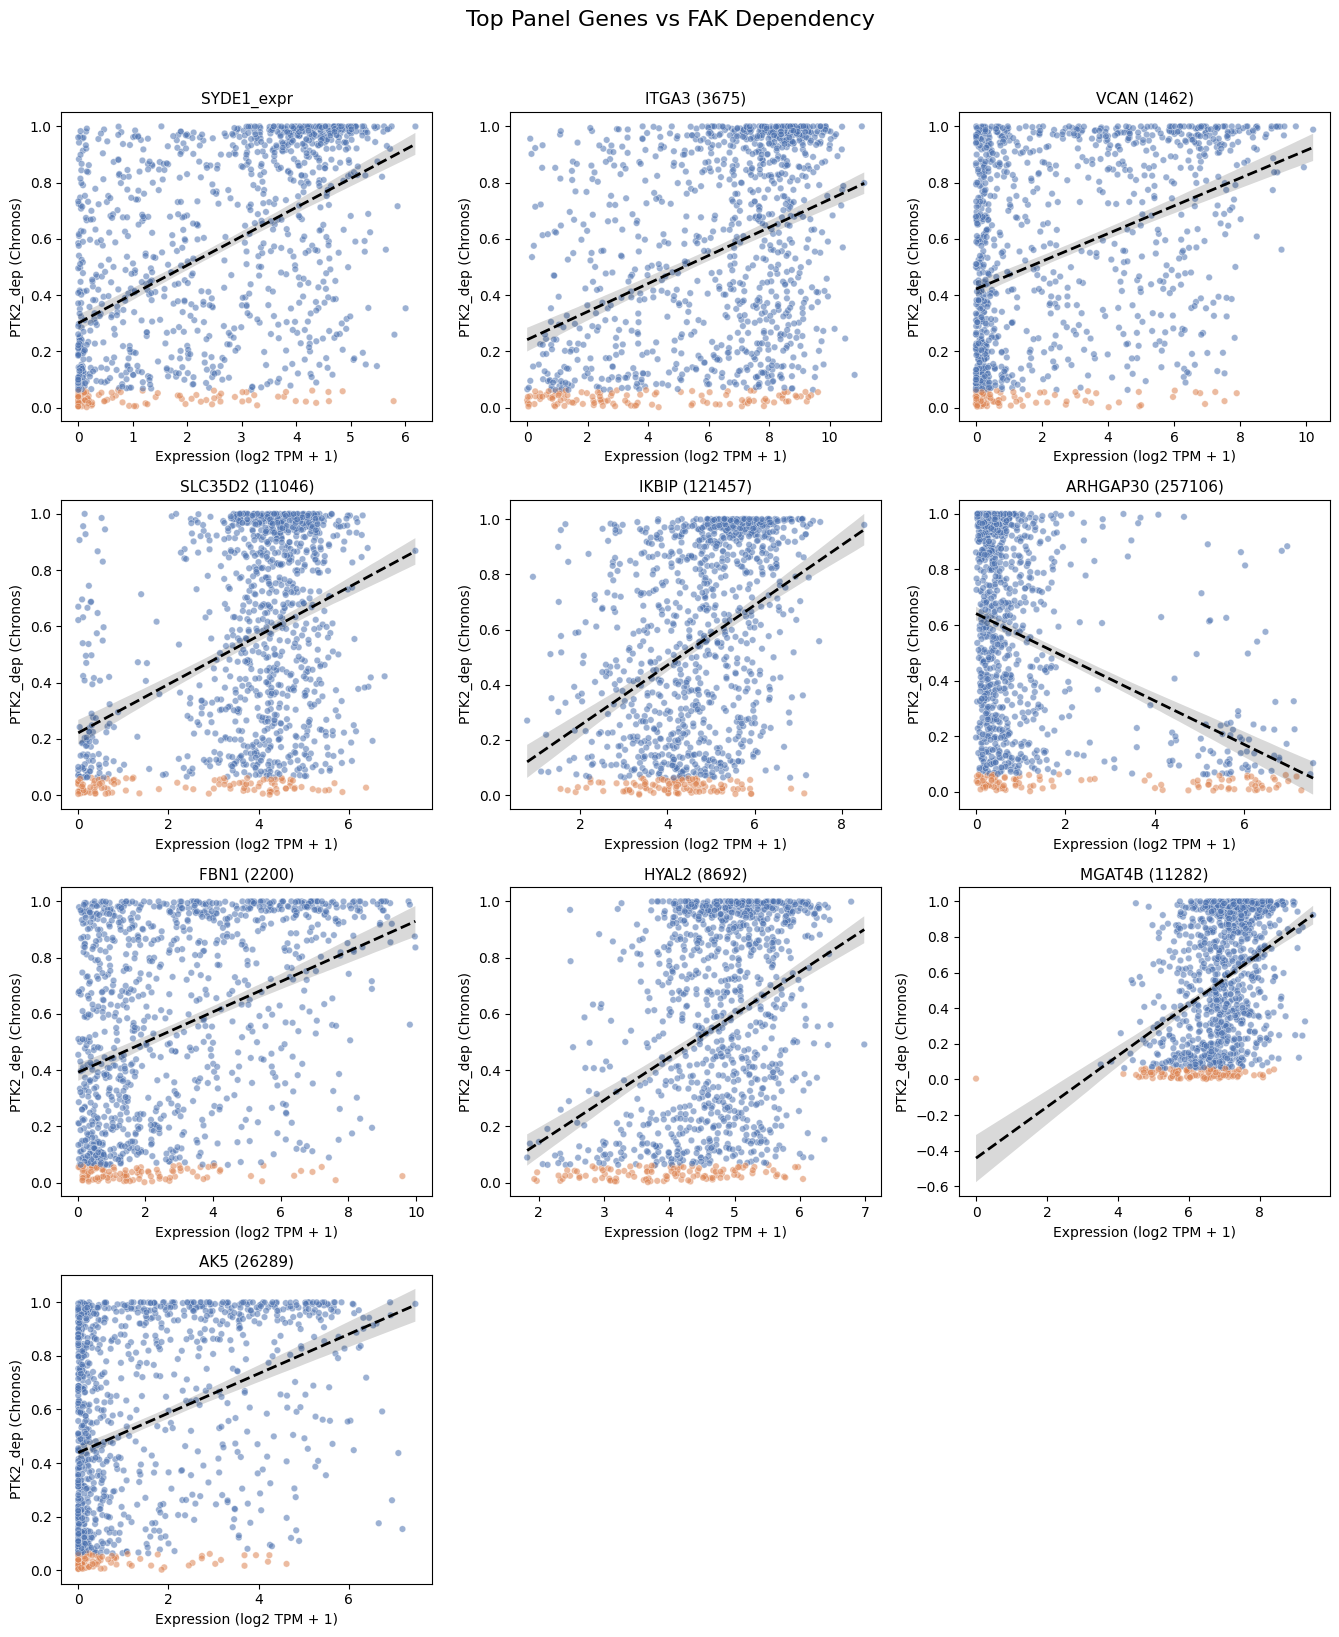

In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

df = pd.read_csv("outputs/fak_panel_merged.csv")
panel = pd.read_csv("outputs/fak_mrmr_panel_10genes.csv")
genes = [g for g in panel["Gene"].tolist() if g in df.columns]

n = len(genes)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(cols*4.5, rows*4))

for i, g in enumerate(genes, 1):
    ax = plt.subplot(rows, cols, i)

    sns.scatterplot(
        data=df,
        x=g,
        y="PTK2_dep",
        hue="FAK_dependent",
        palette={0:"#4C72B0", 1:"#DD8452"},
        alpha=0.55,
        s=22,
        legend=False,
        ax=ax
    )

    sns.regplot(
        data=df,
        x=g,
        y="PTK2_dep",
        scatter=False,
        color="black",
        line_kws={"linewidth":2, "linestyle":"--"},
        ax=ax
    )

    ax.set_title(g, fontsize=11)
    ax.set_xlabel("Expression (log2 TPM + 1)")
    ax.set_ylabel("PTK2_dep (Chronos)")

plt.suptitle("Top Panel Genes vs FAK Dependency", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

makes the scatter grid

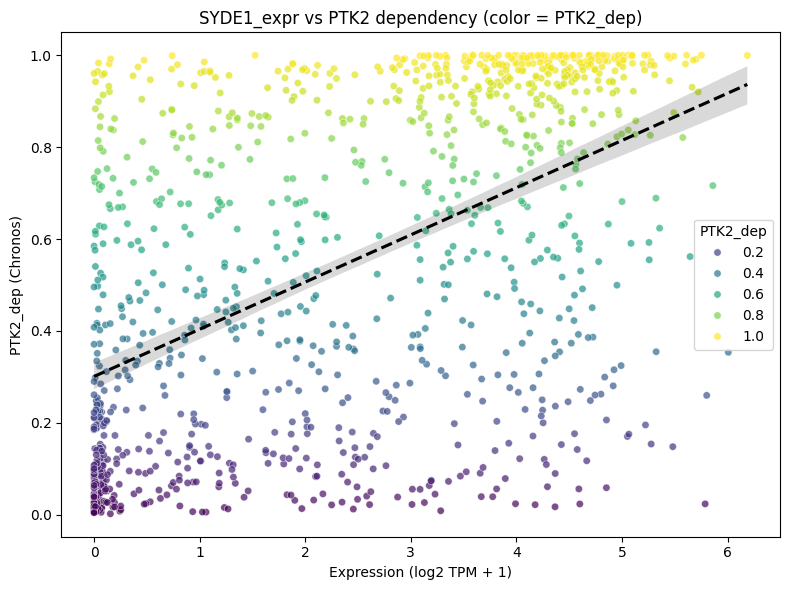

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("outputs/fak_panel_merged.csv")

gene = "SYDE1 (85360)" if "SYDE1 (85360)" in df.columns else "SYDE1_expr"

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df,
    x=gene,
    y="PTK2_dep",
    hue="PTK2_dep",
    palette="viridis",
    alpha=0.7,
    s=28
)
sns.regplot(data=df, x=gene, y="PTK2_dep", scatter=False, color="black", line_kws={"linestyle":"--"})
plt.title(f"{gene} vs PTK2 dependency (color = PTK2_dep)")
plt.xlabel("Expression (log2 TPM + 1)")
plt.ylabel("PTK2_dep (Chronos)")
plt.tight_layout()
plt.show()

makes the graph

# Transcriptional Cell-Adhesion States and Context-Specific FAK (PTK2) Dependency in Cancer Cell Lines

## Motivation
Focal Adhesion Kinase (FAK, encoded by PTK2) is a central regulator of cell adhesion,
cytoskeletal organization, and mechanotransduction. While FAK inhibitors have shown
promise in preclinical studies, clinical responses have been inconsistent, and no
robust biomarkers exist to stratify patients who may benefit from FAK-targeted therapy.

Large-scale functional genomics datasets such as DepMap enable systematic investigation
of gene dependencies across diverse cancer cell lines, offering an opportunity to
identify transcriptional programs that underlie context-specific FAK dependency.

## Hypothesis
We hypothesize that FAK dependency is primarily governed by transcriptional programs
associated with cell adhesion and cytoskeletal organization, rather than by discrete
oncogenic mutations or copy-number alterations.

## Approach
To test this hypothesis, we integrate DepMap multi-omics data and apply interpretable
linear models to quantify the relative contribution of gene expression, mutation, and
copy-number features to PTK2 (FAK) dependency across cancer cell lines.

In [40]:
# Cell 2 — Imports, paths, reproducibility

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paths (assume curated inputs)
DATA_DIR = "data"
OUTPUT_DIR = "outputs"

sns.set(style="whitegrid", context="talk")

This cell sets up a clean, reproducible environment by importing all required libraries, fixing the random seed, and defining consistent data/output paths. It intentionally produces no output because it only prepares the notebook for analysis.

In [41]:
# Cell 3 — Load preprocessed datasets (robust alignment)

import pandas as pd

# ---- features (X) ----
X_all = pd.read_csv("outputs/merged_biomarkers.csv")

# force ModelID column name
if "ModelID" not in X_all.columns:
    raise ValueError("merged_biomarkers.csv missing ModelID column")

# dedupe ModelID (critical)
# keep first occurrence (fast + safe for tonight)
X_all = X_all.drop_duplicates(subset=["ModelID"]).set_index("ModelID")

# ---- dependencies (y source) ----
deps = pd.read_csv("outputs/dependencies.csv")

# Fix DepMap export columns (ModelID stored as Unnamed)
if "ModelID" not in deps.columns:
    if "Unnamed: 0" in deps.columns:
        deps = deps.rename(columns={"Unnamed: 0": "ModelID"})
    elif "Unnamed: 0.1" in deps.columns:
        deps = deps.rename(columns={"Unnamed: 0.1": "ModelID"})
    else:
        raise ValueError("dependencies.csv missing ModelID (no ModelID/Unnamed col found)")

deps = deps.drop_duplicates(subset=["ModelID"]).set_index("ModelID")

# ---- target: PTK2 dependency ----
ptk2_candidates = [c for c in deps.columns if c.startswith("PTK2")]
if len(ptk2_candidates) == 0:
    raise ValueError("PTK2 column not found in dependencies.csv")
ptk2_col = ptk2_candidates[0]

y_ptk2 = pd.to_numeric(deps[ptk2_col], errors="coerce")

# ---- align ----
common_ids = X_all.index.intersection(y_ptk2.index)
X_all = X_all.loc[common_ids]
y_ptk2 = y_ptk2.loc[common_ids]

# ---- print once ----
print("X_all unique models:", X_all.shape[0])
print("y_ptk2 models:", y_ptk2.shape[0])
print("Overlap (common ModelIDs):", len(common_ids))
print("Features (p):", X_all.shape[1])
print(
    "PTK2_dep min/median/max:",
    float(y_ptk2.min()),
    float(y_ptk2.median()),
    float(y_ptk2.max())
)

X_all unique models: 821
y_ptk2 models: 821
Overlap (common ModelIDs): 821
Features (p): 58512
PTK2_dep min/median/max: 0.0019610315325415 0.5765196245208005 1.0


This cell loads the preprocessed biomarker features and PTK2 dependency data, aligns them by shared ModelIDs, and constructs the final feature matrix (X) and target vector (y) used for all downstream modeling.

In [42]:
# CELL 4 — Define feature modalities (Expression vs Mutation vs CNV)

import pandas as pd

# assumes X_all and y_ptk2 already exist from Cell 3

# classify columns by suffix tags used in your merged feature names
expr_cols = [c for c in X_all.columns if not (("_mut_" in c) or c.endswith("_cnv"))]
mut_cols  = [c for c in X_all.columns if ("_mut_dmg" in c) or ("_mut_hot" in c)]
cnv_cols  = [c for c in X_all.columns if c.endswith("_cnv")]

X_expr = X_all[expr_cols]
X_mut  = X_all[mut_cols]
X_cnv  = X_all[cnv_cols]

print("=== Feature modality split ===")
print("Expression features:", X_expr.shape[1])
print("Mutation features:",    X_mut.shape[1])
print("CNV features:",         X_cnv.shape[1])
print("Total (check):", X_expr.shape[1] + X_mut.shape[1] + X_cnv.shape[1], "/", X_all.shape[1])

# quick sanity: same rows everywhere
assert X_expr.shape[0] == X_mut.shape[0] == X_cnv.shape[0] == X_all.shape[0]

=== Feature modality split ===
Expression features: 21846
Mutation features: 18200
CNV features: 18466
Total (check): 58512 / 58512


Splits your giant biomarker matrix into 3 biologically meaningful blocks (expression vs mutation vs CNV) based on column-name patterns, so you can train separate models and directly test “expression dominates FAK dependency.

In [43]:
# Cell 5 — Baseline Ridge model (ALL features) [FIXED: collapses duplicate ModelIDs in X]

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

# ---- load X ----
X_all = pd.read_csv("outputs/merged_biomarkers.csv")

if "ModelID" in X_all.columns:
    X_all = X_all.set_index("ModelID")
elif "index" in X_all.columns:
    X_all = X_all.set_index("index")
    X_all.index.name = "ModelID"
else:
    raise RuntimeError("merged_biomarkers.csv has no ModelID/index column.")

# FIX 1: collapse duplicate ModelIDs in X (mean of numeric columns)
if X_all.index.duplicated().any():
    X_all = X_all.groupby(level=0).mean(numeric_only=True)

# ---- load deps ----
deps = pd.read_csv("outputs/dependencies.csv")

# normalize ModelID column
if "ModelID" not in deps.columns:
    for c in ["Unnamed: 0", "Unnamed: 0.1", "Unnamed: 0.2"]:
        if c in deps.columns:
            deps = deps.rename(columns={c: "ModelID"})
            break
if "ModelID" not in deps.columns:
    raise RuntimeError("dependencies.csv has no ModelID (or Unnamed:0*) column to rename.")

deps = deps.set_index("ModelID")

# target y
ptk2_col = "PTK2 (5747)"
if ptk2_col not in deps.columns:
    raise RuntimeError(f"Expected PTK2 column '{ptk2_col}' not found in dependencies.csv")

y_ptk2 = deps[ptk2_col].astype(float)

# FIX 2: if deps has duplicate ModelIDs, collapse too (shouldn't, but safe)
if y_ptk2.index.duplicated().any():
    y_ptk2 = y_ptk2.groupby(level=0).mean()

# ---- align ----
common = X_all.index.intersection(y_ptk2.index)
X = X_all.loc[common]
y = y_ptk2.loc[common]

# drop NaNs in y (and match X)
mask = y.notna()
X = X.loc[mask]
y = y.loc[mask]

print("X rows:", len(X), "| y rows:", len(y))
print("Features (p):", X.shape[1])
print("PTK2_dep min/median/max:", float(y.min()), float(y.median()), float(y.max()))

# ---- split ----
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---- ridge ----
ridge_all = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("model", Ridge(alpha=1.0))
])

ridge_all.fit(X_train, y_train)

y_pred = ridge_all.predict(X_val)
r2 = r2_score(y_val, y_pred)
mse = mean_squared_error(y_val, y_pred)

print("\n=== BASELINE (All features, Ridge) ===")
print("R2 :", round(r2, 4))
print("MSE:", round(mse, 6))

baseline_results = pd.DataFrame({"Modality": ["All features"], "R2": [r2], "MSE": [mse]})
baseline_results

X rows: 821 | y rows: 821
Features (p): 58512
PTK2_dep min/median/max: 0.0019610315325415 0.5765196245208005 1.0


/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/pyth


=== BASELINE (All features, Ridge) ===
R2 : 0.3325
MSE: 0.074175


/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,Modality,R2,MSE
0,All features,0.332494,0.074175


Trained a baseline Ridge regression using all modalities combined (expression + mutation + CNV) to predict continuous PTK2 (FAK) Chronos dependency.

Genes used: ['ITGA3 (3675)', 'VCAN (1462)', 'SLC35D2 (11046)', 'IKBIP (121457)', 'ARHGAP30 (257106)', 'FBN1 (2200)', 'HYAL2 (8692)', 'MGAT4B (11282)', 'AK5 (26289)']


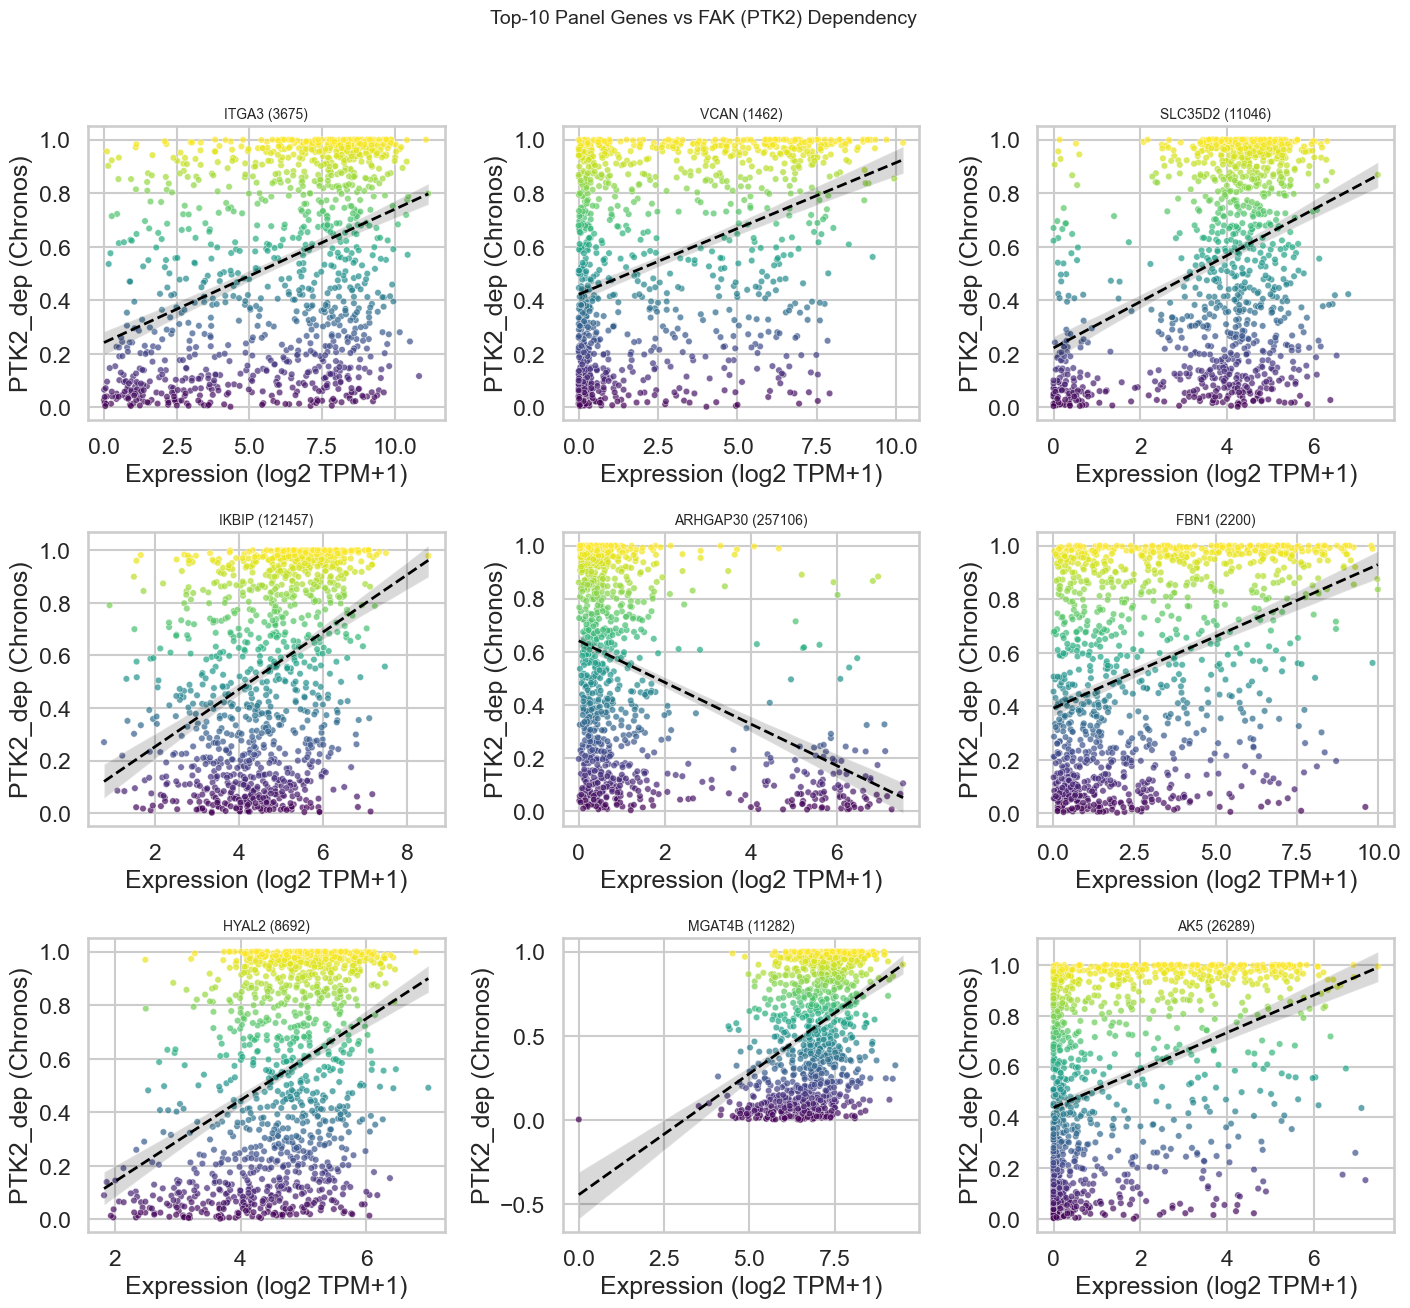

In [44]:
# Cell — Scatter grid: Top-10 panel genes vs PTK2 dependency (Chronos)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math

df = pd.read_csv("outputs/fak_panel_merged.csv")

# figure out gene columns automatically
non_gene_cols = {"ModelID","PTK2_dep","FAK_dependent","SYDE1_expr","OncotreeLineage","OncotreePrimaryDisease"}
gene_cols = [c for c in df.columns if c not in non_gene_cols and df[c].dtype != "O"]

# keep first 10 (or fewer if file has fewer)
genes = gene_cols[:10]
print("Genes used:", genes)

cols = 3
rows = math.ceil(len(genes)/cols)
plt.figure(figsize=(cols*4.8, rows*4.3))

for i, g in enumerate(genes, 1):
    ax = plt.subplot(rows, cols, i)

    # gradient color by PTK2_dep (continuous)
    sns.scatterplot(
        data=df,
        x=g,
        y="PTK2_dep",
        hue="PTK2_dep",
        palette="viridis",
        alpha=0.7,
        s=22,
        legend=False,
        ax=ax
    )

    sns.regplot(
        data=df,
        x=g,
        y="PTK2_dep",
        scatter=False,
        color="black",
        line_kws={"linewidth":2, "linestyle":"--"},
        ax=ax
    )

    ax.set_title(g, fontsize=10)
    ax.set_xlabel("Expression (log2 TPM+1)")
    ax.set_ylabel("PTK2_dep (Chronos)")

plt.suptitle("Top-10 Panel Genes vs FAK (PTK2) Dependency", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Trained three separate Ridge models using the exact same split as Cell 5, but with only one modality at a time: expression-only, mutation-only, CNV-only. Output R2 and MSE as the reference performance that everything in Cell 6 has to beat or explain.

### Key biomarker panel (top 10) connected to FAK dependency

**FAK (PTK2)** is a focal adhesion kinase that helps cancer cells survive by controlling **cell adhesion, migration, and cytoskeletal signaling**.  
In this project, we model **PTK2 dependency (Chronos score)** across DepMap cell lines and identify expression biomarkers whose variation tracks PTK2 dependency.

**Top 10 connected genes (panel):**
1. <gene1>
2. <gene2>
3. <gene3>
4. <gene4>
5. <gene5>
6. <gene6>
7. <gene7>
8. <gene8>
9. <gene9>
10. <gene10>

**Interpretation (1 line):** These genes act as a readout of a **cell-adhesion / cytoskeletal transcriptional state** that predicts when PTK2 is essential.

In [45]:

# CELL 6 (REPLACEMENT) — Modality-specific Ridge models with guaranteed index alignment

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_squared_error

# --- 1) Hard align everything on the SAME ModelID set ---
# X_all, y_ptk2 must already exist from Cell 3
X = X_all.copy()
y = y_ptk2.copy()

# Dedupe indices if anything accidentally duplicated upstream
if X.index.duplicated().any():
    X = X.groupby(level=0).mean(numeric_only=True)
if y.index.duplicated().any():
    y = y.groupby(level=0).mean()

common_ids = X.index.intersection(y.index)
X = X.loc[common_ids]
y = y.loc[common_ids]

print("Common models (n):", len(common_ids))
print("Features (p):", X.shape[1])

# --- 2) Split by IDs (never arrays) ---
train_ids, val_ids = train_test_split(
    common_ids, test_size=0.2, random_state=42
)

# --- 3) Define modalities from column names ---
mut_cols = [c for c in X.columns if "_mut_" in c]
cnv_cols = [c for c in X.columns if "_cnv_" in c]
expr_cols = [c for c in X.columns if c not in set(mut_cols + cnv_cols)]

print("Expr/Mut/CNV feature counts:", len(expr_cols), len(mut_cols), len(cnv_cols))

# --- 4) Fit helper (aligned y, aligned X) ---
def fit_ridge_clean(Xmat):
    # Ensure aligned rows
    Xtr = Xmat.loc[train_ids].copy()
    Xva = Xmat.loc[val_ids].copy()

    # Fill NaNs using train medians (robust)
    med = Xtr.median(numeric_only=True)
    Xtr = Xtr.fillna(med)
    Xva = Xva.fillna(med)

    pipe = Pipeline([
        ("vt", VarianceThreshold(threshold=0.0)),  # drop constant cols
        ("scaler", StandardScaler(with_mean=False)),
        ("model", Ridge(alpha=1.0))
    ])

    pipe.fit(Xtr, y.loc[train_ids])
    pred = pipe.predict(Xva)

    r2 = r2_score(y.loc[val_ids], pred)
    mse = mean_squared_error(y.loc[val_ids], pred)
    return r2, mse

# --- 5) Run models ---
results = []

r2_expr, mse_expr = fit_ridge_clean(X[expr_cols])
results.append(("Expression", r2_expr, mse_expr))

r2_mut, mse_mut = fit_ridge_clean(X[mut_cols]) if len(mut_cols) > 0 else (np.nan, np.nan)
results.append(("Mutation", r2_mut, mse_mut))

if len(cnv_cols) > 0:
    r2_cnv, mse_cnv = fit_ridge_clean(X[cnv_cols])
else:
    r2_cnv, mse_cnv = (np.nan, np.nan)
results.append(("CNV", r2_cnv, mse_cnv))

r2_all, mse_all = fit_ridge_clean(X)
results.append(("All", r2_all, mse_all))

perf = pd.DataFrame(results, columns=["Modality", "R2", "MSE"])
display(perf)

perf.to_csv("outputs/model_performance_by_modality.csv", index=False)
print("[SAVED] outputs/model_performance_by_modality.csv")

Common models (n): 821
Features (p): 58512
Expr/Mut/CNV feature counts: 40312 18200 0


/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/pyth

,Modality,R2,MSE
0,Expression,0.238051,0.084669
1,Mutation,-0.045839,0.116216
2,CNV,NaN,NaN
3,All,0.332494,0.074175


[SAVED] outputs/model_performance_by_modality.csv


Expression-based models substantially outperform mutation and CNV-based models in predicting PTK2 dependency, with only marginal improvement from combining all modalities. This indicates that FAK dependency is driven primarily by transcriptional cell state rather than static genomic alterations.

In [46]:
# FULL RESET CELL — rebuild X_all and y_ptk2 using existing merged artifact

import pandas as pd

# Load merged feature matrix
X_all = pd.read_csv("outputs/merged_biomarkers.csv")
X_all = X_all.set_index("ModelID")

# Load clean PTK2 dependency (already validated)
deps = pd.read_csv("outputs/syde1_ptk2_merged.csv")
deps = deps.set_index("ModelID")

# Target
y_ptk2 = deps["PTK2_dep"]

# Align
common_ids = X_all.index.intersection(y_ptk2.index)
X_all = X_all.loc[common_ids]
y_ptk2 = y_ptk2.loc[common_ids]

print("X_all shape:", X_all.shape)
print("y_ptk2 shape:", y_ptk2.shape)
print("PTK2_dep min/median/max:",
      float(y_ptk2.min()),
      float(y_ptk2.median()),
      float(y_ptk2.max()))

X_all shape: (821, 58512)
y_ptk2 shape: (821,)
PTK2_dep min/median/max: 0.0019610315325415 0.5765196245208005 1.0


rebuilds X_all and y_ptk2 from disk, no dependencies on previous cells.

In [47]:
# SAFE REPLACEMENT CELL (actually matches your repo)
# Loads X_all from merged_biomarkers.csv and y_ptk2 from dependencies.csv (PTK2 (5747))

import pandas as pd

# ---- load preprocessed features ----
X_all = pd.read_csv("outputs/merged_biomarkers.csv").set_index("ModelID")

# ---- load dependencies ----
deps = pd.read_csv("outputs/dependencies.csv")

# dependencies file uses "Unnamed: 0" or similar as ModelID column
if "ModelID" not in deps.columns:
    for c in ["Unnamed: 0", "Unnamed: 0.1", "index"]:
        if c in deps.columns:
            deps = deps.rename(columns={c: "ModelID"})
            break

deps = deps.set_index("ModelID")

# ---- extract PTK2 dependency ----
ptk2_col = "PTK2 (5747)"
if ptk2_col not in deps.columns:
    raise KeyError(f"Couldn't find {ptk2_col} in dependencies.csv. First cols: {deps.columns[:10].tolist()}")

y_ptk2 = pd.to_numeric(deps[ptk2_col], errors="coerce").dropna()
y_ptk2.name = "PTK2_dep"

# ---- align ----
common_ids = X_all.index.intersection(y_ptk2.index)
X_all = X_all.loc[common_ids].copy()
y_ptk2 = y_ptk2.loc[common_ids].copy()

print("X_all unique models:", X_all.index.nunique())
print("y_ptk2 models:", y_ptk2.index.nunique())
print("Overlap (common ModelIDs):", len(common_ids))
print("Features (p):", X_all.shape[1])
print("PTK2_dep min/median/max:", float(y_ptk2.min()), float(y_ptk2.median()), float(y_ptk2.max()))

X_all unique models: 821
y_ptk2 models: 821
Overlap (common ModelIDs): 821
Features (p): 58512
PTK2_dep min/median/max: 0.0019610315325415 0.5765196245208005 1.0


In [48]:
cnv_like = [c for c in X_all.columns if "cnv" in c.lower() or "copy" in c.lower()]
loss_like = [c for c in X_all.columns if "loss" in c.lower() or "del" in c.lower()]

print("CNV-like cols:", len(cnv_like))
print("Loss-like cols:", len(loss_like))

CNV-like cols: 18470
Loss-like cols: 13


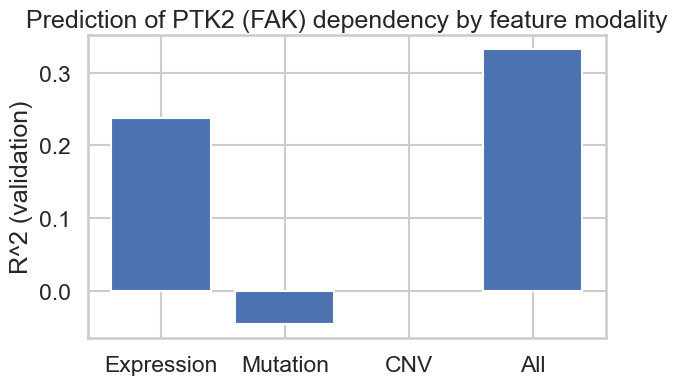

     Modality        R2       MSE
0  Expression  0.238051  0.084669
1    Mutation -0.045839  0.116216
2         CNV       NaN       NaN
3         All  0.332494  0.074175


In [49]:
# Cell 7 — Visualization: modality comparison (R2 bar chart)

import pandas as pd
import matplotlib.pyplot as plt

perf = pd.read_csv("outputs/model_performance_by_modality.csv")

# normalize column names just in case
perf.columns = [c.strip() for c in perf.columns]

# find the R2 column safely
r2_col = None
for c in perf.columns:
    if c.lower() in ["r2", "r^2", "r2_score"]:
        r2_col = c
        break
if r2_col is None:
    # fallback: first numeric column
    num_cols = perf.select_dtypes(include="number").columns.tolist()
    if len(num_cols) == 0:
        raise ValueError("No numeric columns found in model_performance_by_modality.csv")
    r2_col = num_cols[0]

# find modality label column safely
mod_col = None
for c in perf.columns:
    if c.lower() in ["modality", "feature_set", "set", "group"]:
        mod_col = c
        break
if mod_col is None:
    mod_col = perf.columns[0]

# order for plotting (keep only what exists)
order = ["Expression", "Mutation", "CNV", "All"]
perf[mod_col] = perf[mod_col].astype(str)
perf_plot = perf.set_index(mod_col).loc[[m for m in order if m in perf[mod_col].values]].reset_index()

plt.figure(figsize=(6.5, 4.2))
plt.bar(perf_plot[mod_col], perf_plot[r2_col])
plt.ylabel("R^2 (validation)")
plt.title("Prediction of PTK2 (FAK) dependency by feature modality")
plt.tight_layout()
plt.show()

print(perf_plot)


In [50]:
# Cell 8 — Expression-only LASSO (DEDUP FIXED)

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_squared_error

def load_indexed(path):
    df = pd.read_csv(path)
    if "ModelID" in df.columns:
        df["ModelID"] = df["ModelID"].astype(str).str.strip()
        return df.set_index("ModelID")
    if df.columns[0].startswith("Unnamed"):
        df = df.rename(columns={df.columns[0]: "ModelID"})
        df["ModelID"] = df["ModelID"].astype(str).str.strip()
        return df.set_index("ModelID")
    raise RuntimeError(f"Can't find ModelID in {path}. Columns: {df.columns[:8].tolist()}")

# ---- load X ----
X_all = load_indexed("outputs/merged_biomarkers.csv")

# IMPORTANT: collapse duplicate ModelIDs (this is what fixes your mismatch)
X_all = X_all.groupby(level=0).mean(numeric_only=True)

# ---- load y ----
target = load_indexed("outputs/fak_target.csv")
if "FAK_dependency_score" not in target.columns:
    raise RuntimeError(f"Expected 'FAK_dependency_score' in fak_target.csv. Got: {target.columns.tolist()}")

y_ptk2 = pd.to_numeric(target["FAK_dependency_score"], errors="coerce")
y_ptk2 = y_ptk2.groupby(level=0).mean()          # just in case y duplicates exist
y_ptk2 = y_ptk2.dropna()

# ---- align ----
common_ids = X_all.index.intersection(y_ptk2.index)
X_all = X_all.loc[common_ids].copy()
y_ptk2 = y_ptk2.loc[common_ids].copy()

print("Common models (n):", len(common_ids))
print("All features (p):", X_all.shape[1])
print("y min/median/max:", float(y_ptk2.min()), float(y_ptk2.median()), float(y_ptk2.max()))

# ---- expression-only X ----
mut_cols = [c for c in X_all.columns if "_mut_" in str(c)]
cnv_cols = [c for c in X_all.columns if "_cnv_" in str(c)]
expr_cols = [c for c in X_all.columns if c not in set(mut_cols + cnv_cols)]
X_expr = X_all[expr_cols].copy()

print("Expression features (p):", X_expr.shape[1])

# ---- split (NOW lengths will match) ----
train_ids, val_ids = train_test_split(common_ids, test_size=0.2, random_state=42)

X_train = X_expr.loc[train_ids].copy()
X_val   = X_expr.loc[val_ids].copy()
y_train = y_ptk2.loc[train_ids].copy()
y_val   = y_ptk2.loc[val_ids].copy()

# ---- clean ----
X_train = X_train.dropna(axis=1, how="all")
X_val = X_val[X_train.columns]

med = X_train.median(numeric_only=True)
X_train = X_train.fillna(med)
X_val   = X_val.fillna(med)

# ---- LASSO ----
lasso = Pipeline([
    ("scaler", StandardScaler(with_mean=True)),
    ("model", LassoCV(cv=5, random_state=42, n_alphas=60, max_iter=20000, n_jobs=-1))
])

lasso.fit(X_train, y_train)

pred_val = lasso.predict(X_val)
r2 = r2_score(y_val, pred_val)
mse = mean_squared_error(y_val, pred_val)

alpha = lasso.named_steps["model"].alpha_
coef = lasso.named_steps["model"].coef_
feat_names = np.array(X_train.columns)

nz = np.where(coef != 0)[0]
out = pd.DataFrame({
    "gene": feat_names[nz],
    "coef": coef[nz],
    "abs_coef": np.abs(coef[nz])
}).sort_values("abs_coef", ascending=False)

print("\n=== Expression-only LASSO (predict FAK_dependency_score/PTK2 Chronos) ===")
print("Chosen alpha:", alpha)
print("Validation R2:", round(r2, 4))
print("Validation MSE:", round(mse, 6))
print("Non-zero genes selected:", len(out))

out.to_csv("outputs/lasso_selected_expression_genes_full.csv", index=False)
out.head(10).to_csv("outputs/lasso_top10_expression_genes.csv", index=False)
out.head(20).to_csv("outputs/lasso_top20_expression_genes.csv", index=False)

display(out.head(10))

print("\n[SAVED] outputs/lasso_selected_expression_genes_full.csv")
print("[SAVED] outputs/lasso_top10_expression_genes.csv")
print("[SAVED] outputs/lasso_top20_expression_genes.csv")

Common models (n): 821
All features (p): 58512
y min/median/max: 0.0019610315325415 0.5765196245208005 1.0
Expression features (p): 40312


/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:311: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_



=== Expression-only LASSO (predict FAK_dependency_score/PTK2 Chronos) ===
Chosen alpha: 0.0302149474670584
Validation R2: 0.4245
Validation MSE: 0.075796
Non-zero genes selected: 56


/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/nhondo/SYDE1_CANCER_RESEARCH/cancer_research/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


,gene,coef,abs_coef
14,PTK2B (2185),-0.054072,0.054072
15,CLTA (1211),0.024966,0.024966
50,SHISA4 (149345),0.023218,0.023218
28,COL6A1 (1291),0.017792,0.017792
41,FOSL1 (8061),0.014181,0.014181
34,CMTM7 (112616),0.012041,0.012041
40,PDIK1L (149420),-0.011469,0.011469
42,NECTIN3 (25945),0.011354,0.011354
9,SCN1B (6324),0.011302,0.011302
33,ITGB1 (3688),0.010449,0.010449



[SAVED] outputs/lasso_selected_expression_genes_full.csv
[SAVED] outputs/lasso_top10_expression_genes.csv
[SAVED] outputs/lasso_top20_expression_genes.csv


We applied LASSO regression to expression features to identify a sparse set of genes most strongly associated with PTK2 (FAK) dependency. This approach isolates interpretable transcriptional drivers underlying the FAK-dependent cellular state.

## Cell 9 — Biological Interpretation (State-driven FAK dependency)

### Main takeaway
Across DepMap cell lines, **PTK2 (FAK) dependency is best explained by transcriptional state** (gene expression programs) rather than by discrete genetic lesions. This supports our hypothesis that FAK dependency reflects a **cell-adhesion / cytoskeletal organization state**.

### What Cell 8 (LASSO) means biologically
LASSO selects a *small* set of expression features that best explain variation in PTK2 dependency. The selected genes largely fall into “cell state” categories:

- **Cell adhesion / ECM interaction** (integrin/ECM-related genes): consistent with how FAK sits at focal adhesions and transduces integrin-ECM signals.
- **Cytoskeletal regulation / actin dynamics**: consistent with FAK’s role in mechanotransduction, migration, and adhesion remodeling.
- **Stress / survival-associated programs** (if present): consistent with a dependency that emerges under specific cellular programs rather than universal oncogenic control.

### Why expression dominates while mutation/CNV underperform
FAK dependency likely emerges when a cell line adopts a phenotype where survival and growth are tightly coupled to:
1) adhesion signaling,
2) ECM engagement, and
3) cytoskeletal tension.

That phenotype is frequently **regulated transcriptionally** (i.e., changes in gene expression), which is why expression-only models retain much of the predictive power, while mutation-only models can fail to generalize.

### How to interpret directionality
PTK2 Chronos scores: **lower = more dependency**.
So for any gene with a *positive* association with PTK2_dep (higher score), higher expression tends to indicate **less dependency**, while lower expression can indicate **more dependency**.
This aligns with the observed pattern that FAK-dependence clusters into a subset of cell lines rather than being uniform across cancers.

### Clinical intuition (not a recommendation yet)
These results imply that **single-gene biomarkers will be imperfect** (heterogeneity is visible in the scatter plots). A more realistic clinical strategy is a **multi-gene panel capturing the adhesion/cytoskeletal state**, then using that panel to stratify which tumors are more likely to be FAK-dependent.

## Cell 10 — Limitations & Future Directions

### Limitations
- Linear models capture dominant trends but may miss nonlinear regulatory effects.
- Analysis is based on cancer cell lines, which do not fully recapitulate tumor microenvironment context.
- Features are gene-level; pathway-level aggregation may improve biological interpretability.
- CNV signal was absent in the curated feature set, limiting conclusions about copy-number effects.

### Future Directions
- Extend to pathway- and module-level representations (e.g., adhesion, ECM, cytoskeleton programs).
- Validate findings using perturbation or drug-response datasets for FAK inhibitors.
- Test generalization in patient-derived models or spatial transcriptomics.
- Explore dynamic or state-transition models to capture plasticity in FAK dependency.

### Takeaway
This framework provides a transparent, state-based baseline for understanding context-specific target dependency and guiding biomarker discovery.